In [1]:
# variation of skill with season
# variation of skill with initial WR
# variation of skill with ENSO

import copy
import glob
import os
import sys
from datetime import datetime, timedelta
import string

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# import visualkeras
# import tensorflow as tf
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

sys.path.append("/glade/u/home/jhayron/WR_Predictability/3_MLModels/")
from sklearn import datasets, ensemble
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

/glade/work/jhayron/conda-envs/cnn_wr/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def plot_accuracy(weeks, all_accs, best_model, acc_persistence, list_vars, component, indices_component,ax):
    if component == 'lnd':
        component_long = 'land'
        letter_title = 'c) '
    if component == 'atm':
        component_long = 'atmosphere'
        letter_title = 'a) '
    if component == 'ocn':
        component_long = 'ocean'
        letter_title = 'b) '

    list_vars = np.array(list_vars)
    # fig = plt.figure(figsize=(8, 6))

    # Plot individual models
    for acc_temp, name_temp in zip(all_accs, [list_vars[indices_component][i].split('_')[:-1] for i in range(len(indices_component))]):
        ax.plot(weeks, np.array(acc_temp), label=('_'.join(name_temp)).replace('SWVL','SWC').replace('STL','ST'), alpha=0.4)

    # # Plot all variables for the given component
    # acc_temp = [f1_score(pd.read_csv(f'{path_results}results_{component}_week{week}.csv', index_col=0, parse_dates=True)['y_true'],
    #                            pd.read_csv(f'{path_results}results_{component}_week{week}.csv', index_col=0, parse_dates=True)['y_predicted'],
    #                      average='micro')
    #             for week in weeks]
    ax.plot(weeks, all_accs[-1], label=f'All {component_long} variables', color='k', ls='--')

    # Plot best model
    for i, j, d in zip(weeks, np.max(np.array(all_accs), axis=0), best_model):
        ax.scatter(i, j, color='k', marker='*', s=100)
        ax.text(i - 0.25, j + 0.01, s=d.replace('SWVL','SWC').replace('STL','ST'),fontsize=11)

    # Plot persistence
    ax.plot(weeks, acc_persistence, color='red', label='Persistence', ls='dashdot', lw=2)

    # Finalizing plot
    ax.set_ylim(0.15, 0.38)
    ax.set_xlim(0.4, 8.8)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(alpha=0.2)
    ax.set_ylabel('F1 Score',fontsize=14)
    ax.set_xlabel('Lead time [weeks]',fontsize=14)
    ax.set_title(f'{letter_title} Models based on {component_long} variables', loc='left',fontsize=14)
    ax.legend(bbox_to_anchor=(1, 1.0), fontsize=14, ncol=2)
    # ax.legend(fontsize=14, ncol=2)
    # plt.savefig(f'figures/f1_{component}.png', bbox_inches='tight',dpi=300)
    # plt.show()
    # return fig

In [3]:
path_results = "results/"
list_folders = np.sort(glob.glob('/glade/u/home/jhayron/WR_Predictability/6_PCA_xgboost/figures_detrended_20240317/*/'))
list_vars = [list_folders[i].split('/')[-2] for i in range(len(list_folders))]

for ivar,var in enumerate(list_vars):
    print(ivar,var)

indices_atmosphere = np.array([8, 21, 22, 23])
indices_land = np.array([9, 13, 14, 15, 16, 17, 18, 19, 20])
# indices_land = np.array([9,12,13,14,15,16,18,19])
indices_ocean = np.array([0, 1, 2, 3, 4, 5, 6, 7, 10, 12])
# indices_ocean = np.array([0, 1, 2, 3, 4, 5, 6, 7, 10, 12])

0 IC_SODA
1 IT_SODA
2 MLD_SODA
3 OHC100_SODA
4 OHC200_SODA
5 OHC300_SODA
6 OHC50_SODA
7 OHC700_SODA
8 OLR_ERA5
9 SD_ERA5
10 SSH_SODA
11 SST_OISSTv2
12 SST_SODA
13 STL_1m_ERA5
14 STL_28cm_ERA5
15 STL_7cm_ERA5
16 STL_full_ERA5
17 SWVL_1m_ERA5
18 SWVL_28cm_ERA5
19 SWVL_7cm_ERA5
20 SWVL_full_ERA5
21 U10_ERA5
22 U200_ERA5
23 Z500_ERA5
24 Z500_ERA5_Region


In [4]:
names_wr = ["WR1: AR", "WR2: PT", "WR3: GH", "WR4: CUSH", "No WR"]
weeks = np.arange(1, 9)

In [5]:
acc_persistence = np.load('data_figures_2_5/acc_persistence.npy',allow_pickle=True)
dic_ocean = np.load('data_figures_2_5/dic_ocean.npy',allow_pickle=True)[()]
dic_land = np.load('data_figures_2_5/dic_land.npy',allow_pickle=True)[()]
dic_atmosphere = np.load('data_figures_2_5/dic_atmosphere.npy',allow_pickle=True)[()]

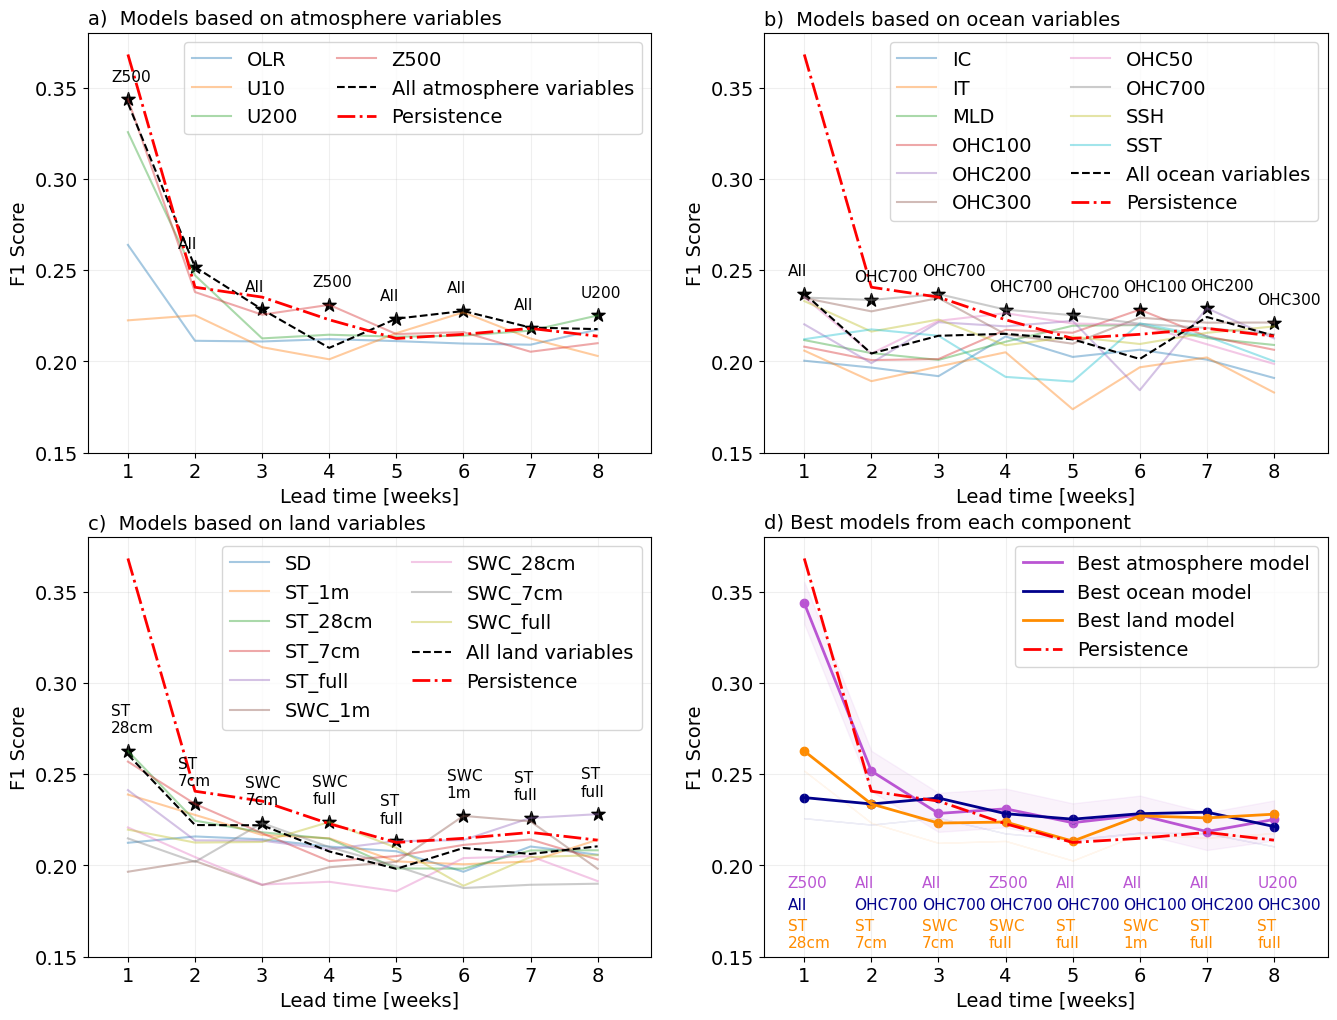

In [6]:
# Create a figure and a set of subplots
fig, axs = plt.subplots(2, 2,figsize=(16,12))  # 2x2 grid of subplots

plot_accuracy(weeks, dic_atmosphere['all_accs_atmosphere'], 
                     dic_atmosphere['best_model_atmosphere'], acc_persistence, 
                     list_vars, 'atm', indices_atmosphere,axs[0,0])

plot_accuracy(weeks, dic_ocean['all_accs_ocean'], 
                     dic_ocean['best_model_ocean'], acc_persistence, 
                     list_vars, 'ocn', indices_ocean,axs[0,1])

plot_accuracy(weeks, dic_land['all_accs_land'], 
                     dic_land['best_model_land'], acc_persistence, 
                     list_vars, 'lnd', indices_land,axs[1,0])


axs[1,1].plot(weeks,dic_atmosphere['best_acc_atmosphere'],label=f'Best atmosphere model',color='mediumorchid',lw=2)
axs[1,1].scatter(weeks,dic_atmosphere['best_acc_atmosphere'],color='mediumorchid')#, s=diff*100)
axs[1,1].plot(weeks,dic_ocean['best_acc_ocean'],label=f'Best ocean model',color='darkblue',lw=2)
axs[1,1].scatter(weeks,dic_ocean['best_acc_ocean'],color='darkblue')
axs[1,1].plot(weeks,dic_land['best_acc_land'],label=f'Best land model',color='darkorange',lw=2)
axs[1,1].scatter(weeks,dic_land['best_acc_land'],color='darkorange')

axs[1,1].fill_between(weeks, dic_atmosphere['best_acc_lower_atmosphere'], 
                 dic_atmosphere['best_acc_upper_atmosphere'], color='mediumorchid', alpha=0.07)
axs[1,1].fill_between(weeks, dic_ocean['best_acc_lower_ocean'], 
                 dic_ocean['best_acc_lower_ocean'], color='darkblue', alpha=0.07)
axs[1,1].fill_between(weeks, dic_land['best_acc_lower_land'], 
                 dic_land['best_acc_lower_land'], color='darkorange', alpha=0.07)

# Plot best model
for i, j, d in zip(weeks, np.max(np.array(dic_atmosphere['all_accs_atmosphere']), axis=0), dic_atmosphere['best_model_atmosphere']):
    axs[1,1].text(i - 0.25, 0.188, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'mediumorchid',fontsize=11)
for i, j, d in zip(weeks, np.max(np.array(dic_ocean['all_accs_ocean']), axis=0), dic_ocean['best_model_ocean']):
    axs[1,1].text(i - 0.25, 0.176, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkblue',fontsize=11)
for i, j, d in zip(weeks, np.max(np.array(dic_land['all_accs_land']), axis=0), dic_land['best_model_land']):
    axs[1,1].text(i - 0.25,  0.155, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkorange',fontsize=11)


axs[1,1].plot(weeks, acc_persistence, color='red', label='Persistence', ls='dashdot', lw=2)
axs[1,1].set_xlim(0.4, 8.8)
axs[1,1].set_ylim(0.15, 0.38)
axs[1,1].tick_params(axis='both', which='major', labelsize=14)
axs[1,1].grid(alpha=0.2)
axs[1,1].set_ylabel('F1 Score',fontsize=14)
axs[1,1].set_xlabel('Lead time [weeks]',fontsize=14)
axs[1,1].set_title(f'd) Best models from each component', loc='left',fontsize=14)
axs[1,1].legend(bbox_to_anchor=(1, 1.0), fontsize=14)
plt.savefig('2_f1Components.pdf',bbox_inches='tight')

# for each season

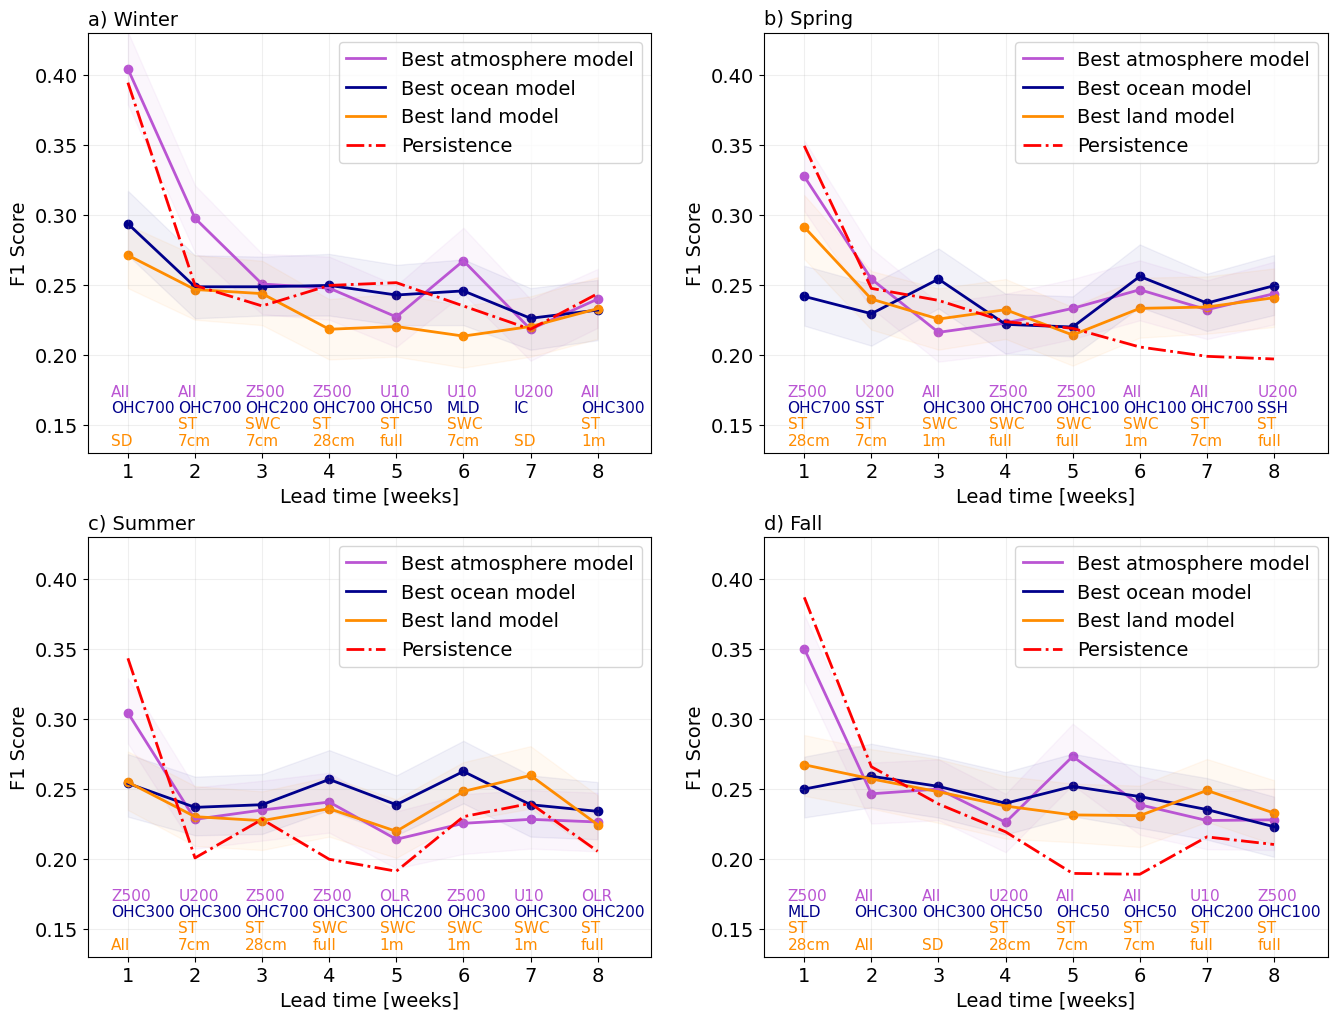

In [7]:
# Call the function with necessary arguments for each season

# Create a figure and a set of subplots
fig, axs = plt.subplots(2, 2,figsize=(16,12))  # 2x2 grid of subplots

# Flatten the axs array and convert to list
axs_list = axs.flatten().tolist()

acc_persistence_seasons = np.load('data_figures_2_5/acc_persistence_seasons.npy',allow_pickle=True)[()]

seasons = ['Winter','Spring','Summer','Fall']

for iseason, season in enumerate(seasons):
    dic_season = np.load(f'data_figures_2_5/dic_{season}.npy',allow_pickle=True)[()]
    component_names = ['atmosphere','ocean','land']

    axs_list[iseason].plot(weeks,dic_season['best_accs']['atmosphere'],label=f'Best atmosphere model',color='mediumorchid',lw=2)
    axs_list[iseason].scatter(weeks,dic_season['best_accs']['atmosphere'],color='mediumorchid')#, s=diff*100)
    axs_list[iseason].plot(weeks,dic_season['best_accs']['ocean'],label=f'Best ocean model',color='darkblue',lw=2)
    axs_list[iseason].scatter(weeks,dic_season['best_accs']['ocean'],color='darkblue')
    axs_list[iseason].plot(weeks,dic_season['best_accs']['land'],label=f'Best land model',color='darkorange',lw=2)
    axs_list[iseason].scatter(weeks,dic_season['best_accs']['land'],color='darkorange')
    
    axs_list[iseason].fill_between(weeks, dic_season['best_acc_lowers']['atmosphere'], 
                     dic_season['best_acc_uppers']['atmosphere'], color='mediumorchid', alpha=0.05)
    axs_list[iseason].fill_between(weeks, dic_season['best_acc_lowers']['ocean'], 
                     dic_season['best_acc_uppers']['ocean'], color='darkblue', alpha=0.05)
    axs_list[iseason].fill_between(weeks, dic_season['best_acc_lowers']['land'], 
                     dic_season['best_acc_uppers']['land'], color='darkorange', alpha=0.05)

    # Plot best model
    for i, j, d in zip(weeks, dic_season['best_accs']['atmosphere'], dic_season['best_names']['atmosphere']):
        axs_list[iseason].text(i - 0.25, 0.17, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'mediumorchid',fontsize=11)
    for i, j, d in zip(weeks, dic_season['best_accs']['ocean'], dic_season['best_names']['ocean']):
        axs_list[iseason].text(i - 0.25, 0.159, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkblue',fontsize=11)
    for i, j, d in zip(weeks, dic_season['best_accs']['land'], dic_season['best_names']['land']):
        axs_list[iseason].text(i - 0.25, 0.135, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkorange',fontsize=11)
        
    
    axs_list[iseason].plot(weeks, np.array(acc_persistence_seasons[season]), color='red', label='Persistence', ls='dashdot', lw=2)
    axs_list[iseason].set_xlim(0.4, 8.8)
    axs_list[iseason].set_ylim(0.13, 0.43)
    axs_list[iseason].tick_params(axis='both', which='major', labelsize=14)
    axs_list[iseason].grid(alpha=0.2)
    axs_list[iseason].set_ylabel('F1 Score',fontsize=14)
    axs_list[iseason].set_xlabel('Lead time [weeks]',fontsize=14)
    axs_list[iseason].legend(bbox_to_anchor=(1, 1.0), fontsize=14)
    abcd = list(string.ascii_lowercase)
    axs_list[iseason].set_title(f'{abcd[iseason]}) {season}',loc='left',fontsize=14)
    # plt.legend(bbox_to_anchor=(1, 0.25))
    # axs_list[iseason].legend(fontsize=14)
    # # aaaa
plt.savefig(f'3_seasonalf1.pdf',bbox_inches='tight')
    # plt.show()
    # plt.close('all')

# for each season and wr

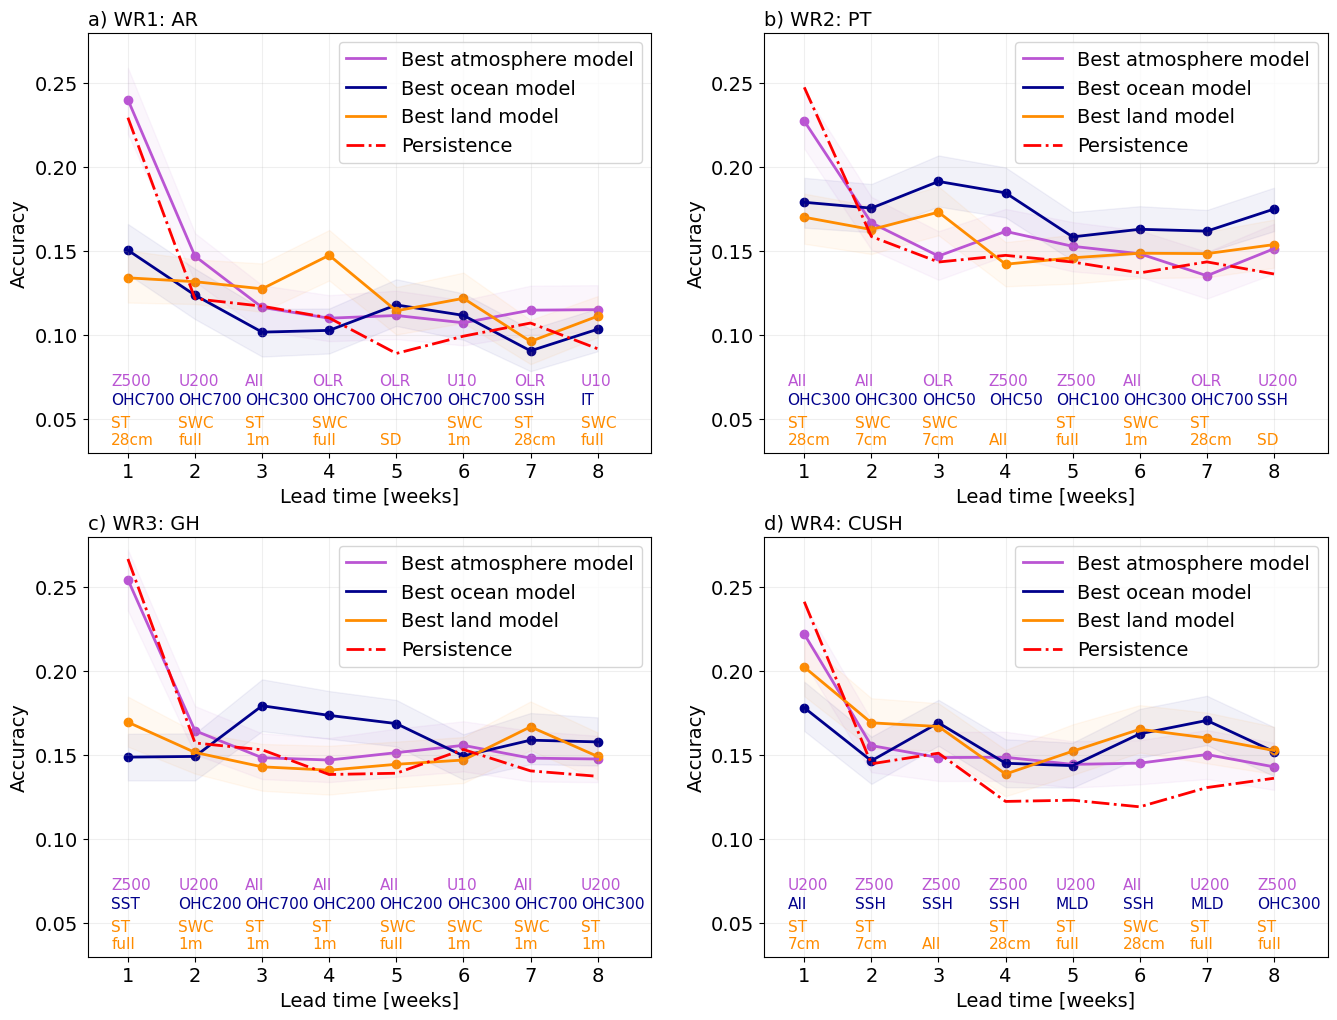

In [8]:
# Call the function with necessary arguments for each season

# Create a figure and a set of subplots
fig, axs = plt.subplots(2, 2,figsize=(16,12))  # 2x2 grid of subplots

# Flatten the axs array and convert to list
axs_list = axs.flatten().tolist()

acc_persistence_wrs = np.load('data_figures_2_5/acc_persistence_wrs.npy',allow_pickle=True)[()]

names_wr = ["WR1: AR", "WR2: PT", "WR3: GH", "WR4: CUSH", "No WR"]

for wr,weather_regime_name in enumerate(names_wr[:-1]):
    dic_wr = np.load(f'data_figures_2_5/dic_{wr}.npy',allow_pickle=True)[()]
    component_names = ['atmosphere','ocean','land']

    axs_list[wr].plot(weeks,dic_wr['best_accs']['atmosphere'],label=f'Best atmosphere model',color='mediumorchid',lw=2)
    axs_list[wr].scatter(weeks,dic_wr['best_accs']['atmosphere'],color='mediumorchid')#, s=diff*100)
    axs_list[wr].plot(weeks,dic_wr['best_accs']['ocean'],label=f'Best ocean model',color='darkblue',lw=2)
    axs_list[wr].scatter(weeks,dic_wr['best_accs']['ocean'],color='darkblue')
    axs_list[wr].plot(weeks,dic_wr['best_accs']['land'],label=f'Best land model',color='darkorange',lw=2)
    axs_list[wr].scatter(weeks,dic_wr['best_accs']['land'],color='darkorange')
    
    axs_list[wr].fill_between(weeks, dic_wr['best_acc_lowers']['atmosphere'], 
                     dic_wr['best_acc_uppers']['atmosphere'], color='mediumorchid', alpha=0.05)
    axs_list[wr].fill_between(weeks, dic_wr['best_acc_lowers']['ocean'], 
                     dic_wr['best_acc_uppers']['ocean'], color='darkblue', alpha=0.05)
    axs_list[wr].fill_between(weeks, dic_wr['best_acc_lowers']['land'], 
                     dic_wr['best_acc_uppers']['land'], color='darkorange', alpha=0.05)

    # Plot best model
    for i, j, d in zip(weeks, dic_wr['best_accs']['atmosphere'], dic_wr['best_names']['atmosphere']):
        axs_list[wr].text(i - 0.25, 0.17-0.1, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'mediumorchid',fontsize=11)
    for i, j, d in zip(weeks, dic_wr['best_accs']['ocean'], dic_wr['best_names']['ocean']):
        axs_list[wr].text(i - 0.25, 0.159-0.1, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkblue',fontsize=11)
    for i, j, d in zip(weeks, dic_wr['best_accs']['land'], dic_wr['best_names']['land']):
        axs_list[wr].text(i - 0.25, 0.135-0.1, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkorange',fontsize=11)
        

    axs_list[wr].plot(weeks, np.array(acc_persistence_wrs[weather_regime_name]), color='red', label='Persistence', ls='dashdot', lw=2)
    axs_list[wr].set_xlim(0.4, 8.8)
    axs_list[wr].set_ylim(0.03, 0.28)
    axs_list[wr].tick_params(axis='both', which='major', labelsize=14)
    axs_list[wr].grid(alpha=0.2)
    axs_list[wr].set_ylabel('Accuracy',fontsize=14)
    axs_list[wr].set_xlabel('Lead time [weeks]',fontsize=14)
    axs_list[wr].legend(bbox_to_anchor=(1, 1.0), fontsize=14)
    abcd = list(string.ascii_lowercase)
    axs_list[wr].set_title(f'{abcd[wr]}) {weather_regime_name}',loc='left',fontsize=14)
    # plt.legend(bbox_to_anchor=(1, 0.25))
    # axs_list[iseason].legend(fontsize=14)
    # # aaaa
    plt.savefig(f'4_AccuracyByWR.pdf',bbox_inches='tight')
    # plt.show()
    # plt.close('all')

# for each WR

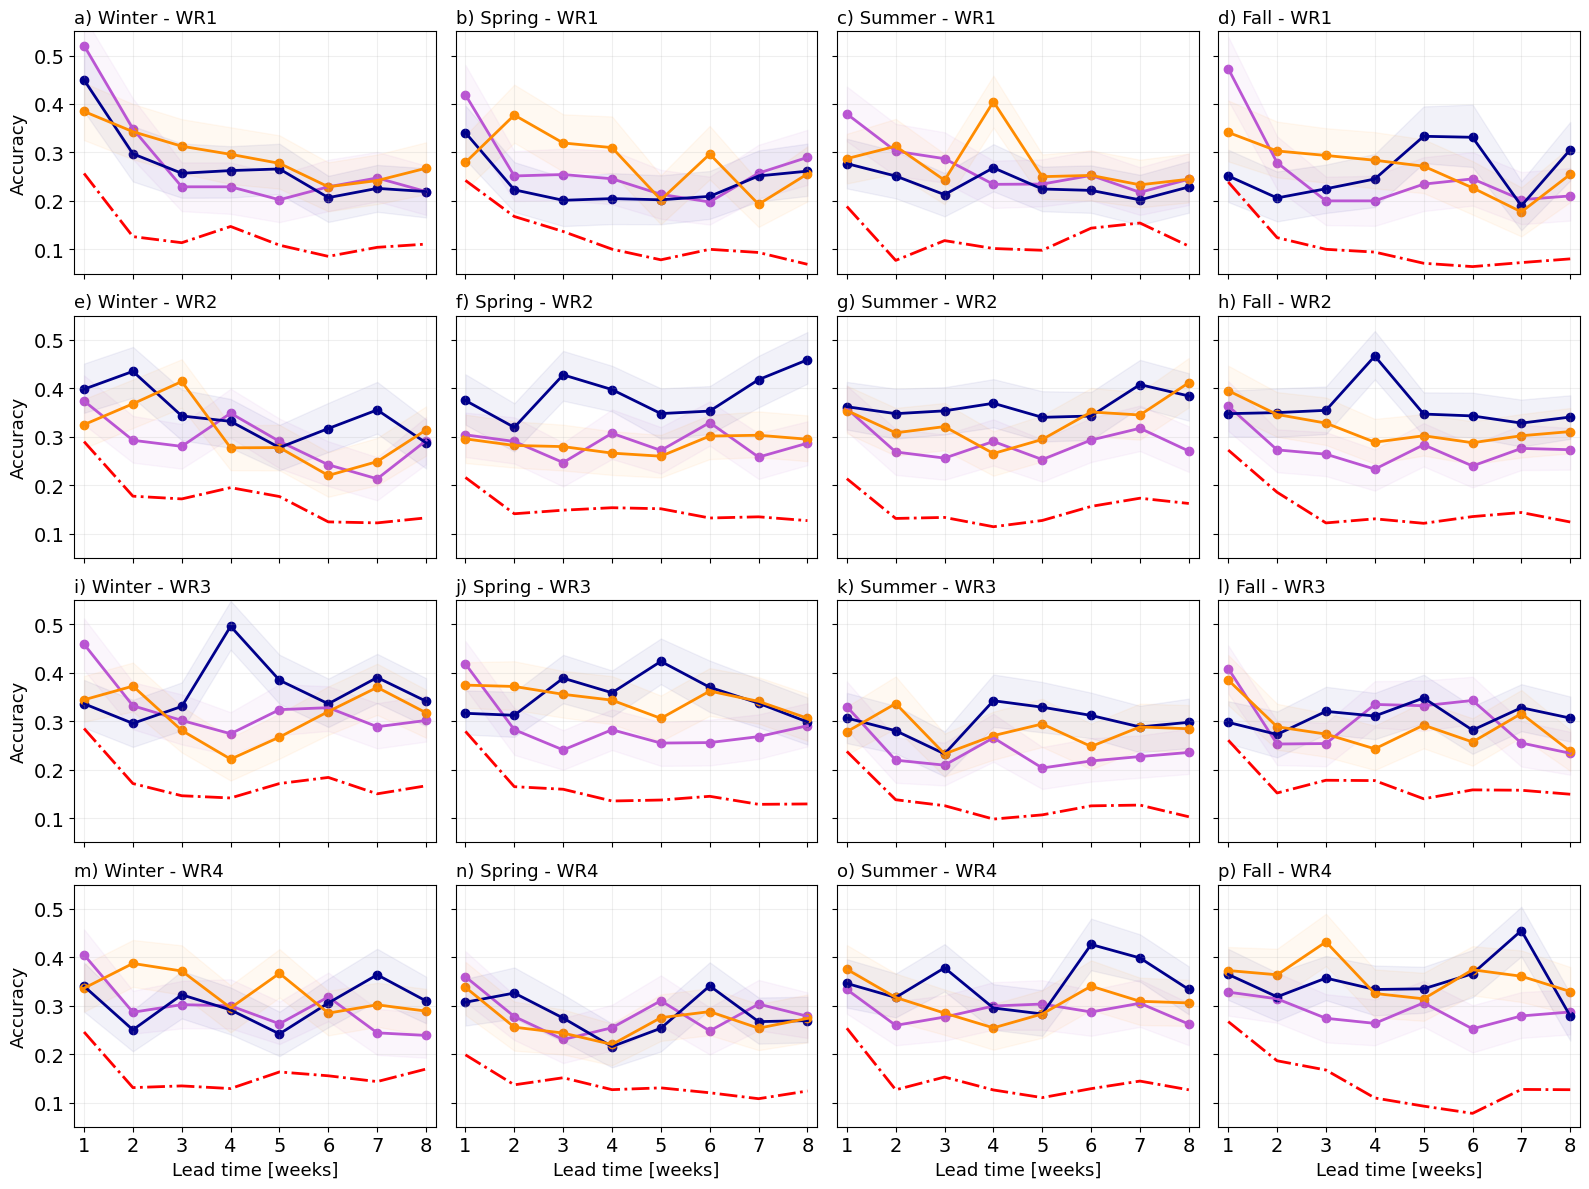

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import string

# Assuming necessary imports and data loading functions are defined

alphabet = list(string.ascii_lowercase)
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
names_wr = ['WR1', 'WR2', 'WR3', 'WR4', 'No WR']
weeks = np.arange(1, 9)

# Create a figure and a set of subplots
fig, axs = plt.subplots(4, 4, figsize=(16, 12))  # 4x4 grid of subplots

dic_accs = np.load(f'data_figures_2_5/dic_accs_stratified.npy', allow_pickle=True)[()]
dic_uppers = np.load(f'data_figures_2_5/dic_uppers_stratified.npy', allow_pickle=True)[()]
dic_lowers = np.load(f'data_figures_2_5/dic_lowers_stratified.npy', allow_pickle=True)[()]
dic_best_names = np.load(f'data_figures_2_5/dic_names_stratified.npy', allow_pickle=True)[()]

for iseason, season in enumerate(seasons):
    for wr, weather_regime_name in enumerate(names_wr[:-1]):
        acc_persistence_seasons = np.load(f'data_figures_2_5/acc_persistence_seasons_{wr}.npy', allow_pickle=True)[()]
        
        dic_accs_temp = dic_accs[wr][season]
        dic_uppers_temp = dic_uppers[wr][season]
        dic_lowers_temp = dic_lowers[wr][season]
        dic_best_names_temp = dic_best_names[wr][season]

        component_names = ['atmosphere', 'ocean', 'land']
    
        axs[wr][iseason].plot(weeks, dic_accs_temp['atm'], label=f'Best atmosphere model', color='mediumorchid', lw=2)
        axs[wr][iseason].scatter(weeks, dic_accs_temp['atm'], color='mediumorchid')
        axs[wr][iseason].plot(weeks, dic_accs_temp['ocn'], label=f'Best ocean model', color='darkblue', lw=2)
        axs[wr][iseason].scatter(weeks, dic_accs_temp['ocn'], color='darkblue')
        axs[wr][iseason].plot(weeks, dic_accs_temp['lnd'], label=f'Best land model', color='darkorange', lw=2)
        axs[wr][iseason].scatter(weeks, dic_accs_temp['lnd'], color='darkorange')
        
        axs[wr][iseason].fill_between(weeks, dic_lowers_temp['atm'], dic_uppers_temp['atm'], color='mediumorchid', alpha=0.05)
        axs[wr][iseason].fill_between(weeks, dic_lowers_temp['ocn'], dic_uppers_temp['ocn'], color='darkblue', alpha=0.05)
        axs[wr][iseason].fill_between(weeks, dic_lowers_temp['lnd'], dic_uppers_temp['lnd'], color='darkorange', alpha=0.05)
    
        axs[wr][iseason].plot(weeks, np.array(acc_persistence_seasons[season]), color='red', label='Persistence', ls='dashdot', lw=2)
        axs[wr][iseason].set_xlim(0.8, 8.2)
        axs[wr][iseason].set_ylim(0.05, 0.55)
        axs[wr][iseason].grid(alpha=0.2)
        # axs[wr][iseason].legend(bbox_to_anchor=(1, 1.0), fontsize=14)

        if iseason % 4 == 0:
            axs[wr][iseason].set_ylabel("Accuracy", fontsize=13)
            axs[wr][iseason].tick_params(axis='both', which='major', labelsize=14)
        else:
            axs[wr][iseason].tick_params(labelleft=False)
        if wr == 3:
            axs[wr][iseason].set_xlabel("Lead time [weeks]", fontsize=13)
            axs[wr][iseason].set_xticks(np.arange(1, 9))
            axs[wr][iseason].tick_params(axis='both', which='major', labelsize=14)
        else:
            axs[wr][iseason].set_xticks(np.arange(1, 9))
            axs[wr][iseason].tick_params(labelbottom=False)
        
        # Calculate the counter based on row and column position
        counter = iseason + wr * len(seasons)
        axs[wr][iseason].set_title(f"{alphabet[counter]}) {season} - {names_wr[wr]}", loc="left", fontsize=13)

plt.tight_layout()
plt.savefig(f'5_accuracy_season_wr.pdf', bbox_inches='tight')

# Tables

In [41]:
import numpy as np
import pandas as pd

# Define your variables
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
names_wr = ["WR1: AR", "WR2: PT", "WR3: GH", "WR4: CUSH", "WR5: No WR"]
weeks = np.arange(1, 9)

# Load your data
dic_best_names = np.load(f'data_figures_2_5/dic_names_stratified.npy', allow_pickle=True)[()]

# Create an empty dictionary to hold DataFrames for each component
dataframes = {}

# Iterate over each component
for component in ['atm', 'ocn', 'lnd']:
    # Create MultiIndex
    index_tuples = []
    data = []

    # Iterate over each weather regime and season to create index and data
    for wr, weather_regime_name in enumerate(names_wr[:-1]):
        for season in seasons:
            index_tuples.append((weather_regime_name, season))
            list_names_temp = dic_best_names[wr][season][component]
            list_names_corrected = [name.replace('SWVL', 'SWC').replace('STL', 'ST') for name in list_names_temp]
            data.append(list_names_corrected)

    # Create a MultiIndex object
    index = pd.MultiIndex.from_tuples(index_tuples, names=['WR', 'Season'])

    # Create the DataFrame
    df = pd.DataFrame(data, index=index, columns=weeks)

    # Store the DataFrame in the dictionary
    dataframes[component] = df

# Now you have three DataFrames in the 'dataframes' dictionary, one for each component
print(dataframes['atm'])
print(dataframes['ocn'])
print(dataframes['lnd'])

# Now you have three DataFrames in the 'dataframes' dictionary, one for each component

# Convert each DataFrame to LaTeX format and save to a file
for component, df in dataframes.items():
    latex_str = df.to_latex()
    with open(f'{component}_dataframe.tex', 'w') as file:
        file.write(latex_str)
    print(f"LaTeX format for {component} DataFrame saved to {component}_dataframe.tex")
    

                     1     2     3     4     5     6     7     8
WR        Season                                                
WR1: AR   Winter  Z500   OLR   OLR  U200   OLR  U200  U200   U10
          Spring  Z500  U200  Z500   OLR   U10   OLR   OLR   U10
          Summer  Z500  U200   OLR   OLR   OLR   U10   U10   U10
          Fall    Z500   OLR  U200  Z500  U200   U10   U10  U200
WR2: PT   Winter  Z500   OLR  Z500  Z500  Z500  Z500  Z500  Z500
          Spring  U200  U200   OLR  Z500  Z500  U200  U200   OLR
          Summer  U200  U200   OLR  Z500   U10  Z500  Z500  U200
          Fall    U200  Z500   OLR  Z500  Z500  Z500   OLR  Z500
WR3: GH   Winter  Z500  U200   U10   U10   U10   U10   U10  U200
          Spring  Z500  U200  U200   U10   OLR  U200  U200  U200
          Summer  Z500  U200   U10  Z500  Z500  Z500  U200   OLR
          Fall    Z500   U10   U10   U10   U10   U10   U10   OLR
WR4: CUSH Winter  U200  U200  U200  Z500  U200   U10  U200  Z500
          Spring  U200  U

/glade/derecho/scratch/jhayron/tmp/ipykernel_4991/3724638931.py:47: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_str = df.to_latex()


In [38]:
dataframes['atm'].to_csv
dataframes['ocn'].to_csv
dataframes['lnd'].to_csv

/glade/derecho/scratch/jhayron/tmp/ipykernel_4991/2398144958.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_str = df.to_latex(multicolumn=True, multirow=True)


LaTeX format for atm DataFrame saved to atm_dataframe.tex
LaTeX format for ocn DataFrame saved to ocn_dataframe.tex
LaTeX format for lnd DataFrame saved to lnd_dataframe.tex


# persistence performance

In [ ]:
wr_series = pd.read_csv('/glade/work/jhayron/Data4Predictability/WR_Series_20231120.csv',\
                index_col=0,names=['week0'],skiprows=1,parse_dates=True)
for wk in range(2,10):
    series_temp = copy.deepcopy(wr_series["week0"])
    series_temp.index = series_temp.index - timedelta(weeks = wk-1)
    series_temp.name = f'week{wk-1}'
    if wk==2:
        df_shifts = pd.concat([pd.DataFrame(wr_series["week0"]),pd.DataFrame(series_temp)],axis=1)  
    else:
        df_shifts = pd.concat([df_shifts,pd.DataFrame(series_temp)],axis=1)

In [ ]:
acc_persistence = []

for wk in range(1, 9):
    df_temp = df_shifts[[f"week{0}", f"week{wk}"]].dropna()  # ['2016':'2020']
    acc_persistence.append(
        f1_score(df_temp[f"week{wk}"], df_temp[f"week{0}"], average="micro")
    )

In [ ]:
acc_persistence = np.array(acc_persistence)

# performance xgb

In [ ]:
path_results = "results/"

In [ ]:
list_folders = np.sort(glob.glob('/glade/u/home/jhayron/WR_Predictability/6_PCA_xgboost/figures_detrended_20240317/*/'))
list_vars = [list_folders[i].split('/')[-2] for i in range(len(list_folders))]

for ivar,var in enumerate(list_vars):
    print(ivar,var)

In [ ]:
indices_atmosphere = np.array([8, 21, 22, 23])
indices_land = np.array([9, 13, 14, 15, 16, 17, 18, 19, 20])
# indices_land = np.array([9,12,13,14,15,16,18,19])
indices_ocean = np.array([0, 1, 2, 3, 4, 5, 6, 7, 10, 12])
# indices_ocean = np.array([0, 1, 2, 3, 4, 5, 6, 7, 10, 12])

In [ ]:
# Define weeks
weeks = np.arange(1, 9)

In [ ]:
np.random.seed(42)

## Evaluate atmospheric variables

In [ ]:
def compute_accuracy_and_range(results_temp):
    accuracy_iterations = []
    for _ in range(100):  # Adjust the number of iterations as needed
        sample_indices = np.random.choice(results_temp.index, size=int(len(results_temp)), replace=True)
        sampled_data = results_temp.loc[sample_indices]
        accuracy_iterations.append(f1_score(sampled_data['y_true'], sampled_data['y_predicted'],average='micro'))
    # accuracy_mean = np.mean(accuracy_iterations)
    accuracy_mean = f1_score(results_temp['y_true'],results_temp['y_predicted'],average='micro')
    accuracy_95th = np.percentile(accuracy_iterations,95)
    accuracy_5th = np.percentile(accuracy_iterations,5)
    return accuracy_mean, accuracy_95th, accuracy_5th
    
def process_results(indices, list_vars, path_results):
    all_accs = []
    all_uppers = []
    all_lowers = []
    
    weeks = np.arange(1, 9)
    
    for ivar in range(len(indices)):
        name_temp = list_vars[indices[ivar]]
        acc_temp = []
        acc_upper_temp = []
        acc_lower_temp = []
        for week in weeks:
            results_temp = pd.read_csv(f'{path_results}results_{name_temp}_week{week}.csv', index_col=0, parse_dates=True)
            acc_mean, acc_upper, acc_lower = compute_accuracy_and_range(results_temp)
            acc_temp.append(acc_mean)
            acc_upper_temp.append(acc_upper)
            acc_lower_temp.append(acc_lower)
        all_accs.append(acc_temp)
        all_uppers.append(acc_upper_temp)
        all_lowers.append(acc_lower_temp)
    
    if 'SSH_SODA' in np.array(list_vars)[indices]:
        component = 'ocn'
    if 'Z500_ERA5' in np.array(list_vars)[indices]:
        component = 'atm'
    if 'SWVL_full_ERA5' in np.array(list_vars)[indices]:
        component = 'lnd'
        
    ## the joint model
    name_temp = 'ALL'
    acc_temp = []
    acc_upper_temp = []
    acc_lower_temp = []
    for week in weeks:
        results_temp = pd.read_csv(f'{path_results}results_{component}_week{week}.csv', index_col=0, parse_dates=True)
        acc_mean, acc_upper, acc_lower = compute_accuracy_and_range(results_temp)
        acc_temp.append(acc_mean)
        acc_upper_temp.append(acc_upper)
        acc_lower_temp.append(acc_lower)
    all_accs.append(acc_temp)
    all_uppers.append(acc_upper_temp)
    all_lowers.append(acc_lower_temp)
    
    ind_max_acc = np.argmax(np.array(all_accs), axis=0)
    
    best_model = []
    for ind in ind_max_acc:
        if ind<len(indices):
            best_model.append('\n'.join(list_vars[indices[ind]].split('_')[:-1]))
        else:
            best_model.append('All')
    print(best_model)
    # best_model = ['\n'.join(list_vars[indices[ind]].split('_')[:-1]) for ind in ind_max_acc]
    
    max_acc_upper = [np.array(all_uppers)[ind_max_acc[i], i] for i in range(len(ind_max_acc))]
    max_acc_lower = [np.array(all_lowers)[ind_max_acc[i], i] for i in range(len(ind_max_acc))]
    
    best_model_all = best_model
    best_acc_all = np.max(np.array(all_accs), axis=0)
    best_acc_upper_all = np.array(max_acc_upper)
    best_acc_lower_all = np.array(max_acc_lower)
    mean_acc_all = np.mean(np.array(all_accs), axis=0)
    diff_acc_all = best_acc_all - mean_acc_all
    
    return all_accs, all_uppers, all_lowers, best_model_all, best_acc_all, \
        best_acc_upper_all, best_acc_lower_all, mean_acc_all, diff_acc_all
    
def plot_accuracy(weeks, all_accs, best_model, acc_persistence, list_vars, component, indices_component):
    if component == 'lnd':
        component_long = 'land'
        letter_title = 'c) '
    if component == 'atm':
        component_long = 'atmosphere'
        letter_title = 'a) '
    if component == 'ocn':
        component_long = 'ocean'
        letter_title = 'b) '

    list_vars = np.array(list_vars)
    plt.figure(figsize=(8, 6))

    # Plot individual models
    for acc_temp, name_temp in zip(all_accs, [list_vars[indices_component][i].split('_')[:-1] for i in range(len(indices_component))]):
        plt.plot(weeks, np.array(acc_temp), label=('_'.join(name_temp)).replace('SWVL','SWC').replace('STL','ST'), alpha=0.4)

    # # Plot all variables for the given component
    # acc_temp = [f1_score(pd.read_csv(f'{path_results}results_{component}_week{week}.csv', index_col=0, parse_dates=True)['y_true'],
    #                            pd.read_csv(f'{path_results}results_{component}_week{week}.csv', index_col=0, parse_dates=True)['y_predicted'],
    #                      average='micro')
    #             for week in weeks]
    plt.plot(weeks, all_accs[-1], label=f'All {component_long} variables', color='k', ls='--')

    # Plot best model
    for i, j, d in zip(weeks, np.max(np.array(all_accs), axis=0), best_model):
        plt.scatter(i, j, color='k', marker='*', s=100)
        plt.text(i - 0.25, j + 0.01, s=d.replace('SWVL','SWC').replace('STL','ST'),fontsize=11)

    # Plot persistence
    plt.plot(weeks, acc_persistence, color='red', label='Persistence', ls='dashdot', lw=2)

    # Finalizing plot
    plt.ylim(0.15, 0.38)
    plt.xlim(0.4, 8.6)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(alpha=0.2)
    plt.ylabel('F1 Score',fontsize=14)
    plt.xlabel('Lead time [weeks]',fontsize=14)
    plt.title(f'{letter_title} Models based on {component_long} variables', loc='left',fontsize=14)
    plt.legend(bbox_to_anchor=(1, 1.0), fontsize=14, ncol=2)
    plt.savefig(f'figures/f1_{component}.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
# Call the function with necessary arguments for ocean
all_accs_ocean, all_uppers_ocean, all_lowers_ocean, best_model_ocean, best_acc_ocean, \
    best_acc_upper_ocean, best_acc_lower_ocean, mean_acc_ocean, diff_acc_ocean = process_results(indices_ocean, list_vars, path_results)

# Call the function with necessary arguments for land
all_accs_land, all_uppers_land, all_lowers_land, best_model_land, best_acc_land, \
    best_acc_upper_land, best_acc_lower_land, mean_acc_land, diff_acc_land = process_results(indices_land, list_vars, path_results)

# Call the function with necessary arguments for atmosphere
all_accs_atmosphere, all_uppers_atmosphere, all_lowers_atmosphere, best_model_atmosphere, best_acc_atmosphere, \
    best_acc_upper_atmosphere, best_acc_lower_atmosphere, mean_acc_atmosphere, diff_acc_atmosphere = process_results(indices_atmosphere, list_vars, path_results)

In [ ]:
# # Example usage for ocean component
component = 'ocn'
plot_accuracy(weeks, all_accs_ocean, best_model_ocean, acc_persistence, list_vars, component, indices_ocean)

# # Example usage for land component
component = 'lnd'
plot_accuracy(weeks, all_accs_land, best_model_land, acc_persistence, list_vars, component, indices_land)

# Example usage for atmosphere component
component = 'atm'
plot_accuracy(weeks, all_accs_atmosphere, best_model_atmosphere, acc_persistence, list_vars, component, indices_atmosphere)


In [ ]:
# from PIL import Image

# # Open the images
# image1 = Image.open('figures/f1_atm.png')
# image2 = Image.open('figures/f1_ocn.png')
# image3 = Image.open('figures/f1_lnd.png')

# # Ensure all images have the same width
# min_width = min(image1.width, image2.width, image3.width)
# image1 = image1.crop((0, 0, min_width, image1.height))
# image2 = image2.crop((0, 0, min_width, image2.height))
# image3 = image3.crop((0, 0, min_width, image3.height))

# # Concatenate the images vertically
# concatenated_image = Image.new('RGB', (min_width, image1.height + image2.height + image3.height))
# concatenated_image.paste(image1, (0, 0))
# concatenated_image.paste(image2, (0, image1.height))
# concatenated_image.paste(image3, (0, image1.height + image2.height))

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(weeks,best_acc_atmosphere,label=f'Best atmosphere model',color='mediumorchid',lw=2)
plt.scatter(weeks,best_acc_atmosphere,color='mediumorchid')#, s=diff*100)
plt.plot(weeks,best_acc_ocean,label=f'Best ocean model',color='darkblue',lw=2)
plt.scatter(weeks,best_acc_ocean,color='darkblue')
plt.plot(weeks,best_acc_land,label=f'Best land model',color='darkorange',lw=2)
plt.scatter(weeks,best_acc_land,color='darkorange')

plt.fill_between(weeks, best_acc_lower_atmosphere, 
                 best_acc_upper_atmosphere, color='mediumorchid', alpha=0.07)
plt.fill_between(weeks, best_acc_lower_ocean, 
                 best_acc_upper_ocean, color='darkblue', alpha=0.07)
plt.fill_between(weeks, best_acc_lower_land, 
                 best_acc_upper_land, color='darkorange', alpha=0.07)

# Plot best model
for i, j, d in zip(weeks, np.max(np.array(all_accs_atmosphere), axis=0), best_model_atmosphere):
    plt.text(i - 0.25, 0.18, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'mediumorchid',fontsize=11)
for i, j, d in zip(weeks, np.max(np.array(all_accs_ocean), axis=0), best_model_ocean):
    plt.text(i - 0.25, 0.171, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkblue',fontsize=11)
for i, j, d in zip(weeks, np.max(np.array(all_accs_land), axis=0), best_model_land):
    plt.text(i - 0.25,  0.155, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkorange',fontsize=11)


plt.plot(weeks, acc_persistence, color='red', label='Persistence', ls='dashdot', lw=2)
plt.xlim(0.4, 8.6)
plt.ylim(0.15, 0.38)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.2)
plt.ylabel('F1 Score',fontsize=14)
plt.xlabel('Lead time [weeks]',fontsize=14)
plt.title(f'd) Best models from each component', loc='left',fontsize=14)
plt.legend(bbox_to_anchor=(1, 1.0), fontsize=14)
plt.savefig('figures/f1_3comps_100.pdf',bbox_inches='tight')

In [ ]:
from PIL import Image

# Open the images
image1 = Image.open('figures/f1_atm.png')
image2 = Image.open('figures/f1_ocn.png')
image3 = Image.open('figures/f1_lnd.png')
image4 = Image.open('figures/f1_3comps_100.png')  # Path to your fourth image

# Ensure all images have the same width and height
min_width = min(image1.width, image2.width, image3.width, image4.width)
min_height = min(image1.height, image2.height, image3.height, image4.height)
image1 = image1.crop((0, 0, min_width, min_height))
image2 = image2.crop((0, 0, min_width, min_height))
image3 = image3.crop((0, 0, min_width, min_height))
image4 = image4.crop((0, 0, min_width, min_height))

# Concatenate the images horizontally
concatenated_top = Image.new('RGB', (min_width * 2, min_height))
concatenated_top.paste(image1, (0, 0))
concatenated_top.paste(image2, (min_width, 0))

concatenated_bottom = Image.new('RGB', (min_width * 2, min_height))
concatenated_bottom.paste(image3, (0, 0))
concatenated_bottom.paste(image4, (min_width, 0))

# Concatenate the images vertically
concatenated_image = Image.new('RGB', (min_width * 2, min_height * 2))
concatenated_image.paste(concatenated_top, (0, 0))
concatenated_image.paste(concatenated_bottom, (0, min_height))

# Save the concatenated image
concatenated_image.save('2_f1Components_100.png')

# Check for seasons

In [ ]:
indices_seasons = {'Winter':[12,1,2],
                   'Spring':[3,4,5],
                   'Summer':[6,7,8],
                   'Fall':[9,10,11]}

acc_persistence_seasons = {}
for season in indices_seasons.keys():
    acc_persistence_temp = []
    for wk in range(1,9):
        df_temp = df_shifts[[f'week{0}',f'week{wk}']].dropna()
        df_temp = df_temp[(df_temp.index.month==indices_seasons[season][0])|\
                                    (df_temp.index.month==indices_seasons[season][1])|\
                                    (df_temp.index.month==indices_seasons[season][2])]
        acc_persistence_temp.append(f1_score(df_temp[f'week{wk}'],df_temp[f'week{0}'],average='micro'))
    acc_persistence_seasons[season] = acc_persistence_temp

In [ ]:
def process_results_with_seasons(indices, list_vars, path_results, indices_seasons, season):
    all_accs = []
    all_uppers = []
    all_lowers = []
    weeks = np.arange(1, 9)
    
    for ivar in range(len(indices)):
        name_temp = list_vars[indices[ivar]]
        acc_temp = []
        acc_upper_temp = []
        acc_lower_temp = []
        
        for week in weeks:
            results_temp = pd.read_csv(f'{path_results}results_{name_temp}_week{week}.csv', index_col=0, parse_dates=True)
            results_temp = results_temp[(results_temp.index.month==indices_seasons[season][0])|\
                            (results_temp.index.month==indices_seasons[season][1])|\
                            (results_temp.index.month==indices_seasons[season][2])]
            
            acc_mean, acc_upper, acc_lower = compute_accuracy_and_range(results_temp)
            acc_temp.append(acc_mean)
            acc_upper_temp.append(acc_upper)
            acc_lower_temp.append(acc_lower)
        
        all_accs.append(acc_temp)
        all_uppers.append(acc_upper_temp)
        all_lowers.append(acc_lower_temp)
        
    if 'SSH_SODA' in np.array(list_vars)[indices]:
        component = 'ocn'
    if 'Z500_ERA5' in np.array(list_vars)[indices]:
        component = 'atm'
    if 'SWVL_full_ERA5' in np.array(list_vars)[indices]:
        component = 'lnd'
        
    ## the joint model
    name_temp = 'ALL'
    acc_temp = []
    acc_upper_temp = []
    acc_lower_temp = []
    for week in weeks:
        results_temp = pd.read_csv(f'{path_results}results_{component}_week{week}.csv', index_col=0, parse_dates=True)
        results_temp = results_temp[(results_temp.index.month==indices_seasons[season][0])|\
                        (results_temp.index.month==indices_seasons[season][1])|\
                        (results_temp.index.month==indices_seasons[season][2])]
        acc_mean, acc_upper, acc_lower = compute_accuracy_and_range(results_temp)
        acc_temp.append(acc_mean)
        acc_upper_temp.append(acc_upper)
        acc_lower_temp.append(acc_lower)
    all_accs.append(acc_temp)
    all_uppers.append(acc_upper_temp)
    all_lowers.append(acc_lower_temp)
    
    ind_max_acc = np.argmax(np.array(all_accs), axis=0)
    
    best_model = []
    for ind in ind_max_acc:
        if ind<len(indices):
            best_model.append('\n'.join(list_vars[indices[ind]].split('_')[:-1]))
        else:
            best_model.append('All')

    max_acc_upper = [np.array(all_uppers)[ind_max_acc[i], i] for i in range(len(ind_max_acc))]
    max_acc_lower = [np.array(all_lowers)[ind_max_acc[i], i] for i in range(len(ind_max_acc))]

    best_model_all = best_model
    best_acc_all = np.max(np.array(all_accs), axis=0)
    best_acc_upper_all = np.array(max_acc_upper)
    best_acc_lower_all = np.array(max_acc_lower)
    mean_acc_all = np.mean(np.array(all_accs), axis=0)
    diff_acc_all = best_acc_all - mean_acc_all
    
    return all_accs, all_uppers, all_lowers, best_model_all, best_acc_all, \
        best_acc_upper_all, best_acc_lower_all, mean_acc_all, diff_acc_all
    

In [ ]:
# Call the function with necessary arguments for each season
for iseason, season in enumerate(indices_seasons.keys()):
    best_accs = {}
    best_acc_uppers = {}
    best_acc_lowers = {}
    best_names = {}
    component_names = ['atmosphere','ocean','land']
    for indices_component, component in zip([indices_atmosphere, indices_ocean, indices_land], component_names):
        all_accs, all_uppers, all_lowers, best_model, best_acc, \
            best_acc_upper, best_acc_lower, mean_acc, diff_acc = \
                process_results_with_seasons(indices_component, list_vars, path_results, indices_seasons, season)
        best_accs[component] = best_acc
        best_acc_uppers[component] = best_acc_upper
        best_acc_lowers[component] = best_acc_lower
        best_names[component] = best_model
        print(best_names[component])

    plt.figure(figsize=(8, 7))
    
    plt.plot(weeks,best_accs['atmosphere'],label=f'Best atmosphere model',color='mediumorchid',lw=2)
    plt.scatter(weeks,best_accs['atmosphere'],color='mediumorchid')#, s=diff*100)
    plt.plot(weeks,best_accs['ocean'],label=f'Best ocean model',color='darkblue',lw=2)
    plt.scatter(weeks,best_accs['ocean'],color='darkblue')
    plt.plot(weeks,best_accs['land'],label=f'Best land model',color='darkorange',lw=2)
    plt.scatter(weeks,best_accs['land'],color='darkorange')
    
    plt.fill_between(weeks, best_acc_lowers['atmosphere'], 
                     best_acc_uppers['atmosphere'], color='mediumorchid', alpha=0.05)
    plt.fill_between(weeks, best_acc_lowers['ocean'], 
                     best_acc_uppers['ocean'], color='darkblue', alpha=0.05)
    plt.fill_between(weeks, best_acc_lowers['land'], 
                     best_acc_uppers['land'], color='darkorange', alpha=0.05)

    # Plot best model
    for i, j, d in zip(weeks, best_accs['atmosphere'], best_names['atmosphere']):
        plt.text(i - 0.25, 0.18, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'mediumorchid',fontsize=11)
    for i, j, d in zip(weeks, best_accs['ocean'], best_names['ocean']):
        plt.text(i - 0.25, 0.171, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkblue',fontsize=11)
    for i, j, d in zip(weeks, best_accs['land'], best_names['land']):
        plt.text(i - 0.25, 0.155, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkorange',fontsize=11)

    
    plt.plot(weeks, np.array(acc_persistence_seasons[season]), color='red', label='Persistence', ls='dashdot', lw=2)
    plt.xlim(0.4, 8.6)
    plt.ylim(0.15, 0.43)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(alpha=0.2)
    plt.ylabel('F1 Score',fontsize=14)
    plt.xlabel('Lead time [weeks]',fontsize=14)
    plt.legend(bbox_to_anchor=(1, 1.0), fontsize=14)
    abcd = list(string.ascii_lowercase)
    plt.title(f'{abcd[iseason]}) {season}',loc='left',fontsize=14)
    # plt.legend(bbox_to_anchor=(1, 0.25))
    plt.legend(fontsize=14)
    # aaaa
    plt.savefig(f'figures/f1_3comps_{season}.png',bbox_inches='tight')
    plt.show()
    plt.close('all')

In [ ]:
from PIL import Image

# Open the images
image1 = Image.open('figures/f1_3comps_Winter.png')
image2 = Image.open('figures/f1_3comps_Spring.png')
image3 = Image.open('figures/f1_3comps_Summer.png')
image4 = Image.open('figures/f1_3comps_Fall.png')  # Path to your fourth image

# Ensure all images have the same width and height
min_width = min(image1.width, image2.width, image3.width, image4.width)
min_height = min(image1.height, image2.height, image3.height, image4.height)
image1 = image1.crop((0, 0, min_width, min_height))
image2 = image2.crop((0, 0, min_width, min_height))
image3 = image3.crop((0, 0, min_width, min_height))
image4 = image4.crop((0, 0, min_width, min_height))

# Concatenate the images horizontally
concatenated_top = Image.new('RGB', (min_width * 2, min_height))
concatenated_top.paste(image1, (0, 0))
concatenated_top.paste(image2, (min_width, 0))

concatenated_bottom = Image.new('RGB', (min_width * 2, min_height))
concatenated_bottom.paste(image3, (0, 0))
concatenated_bottom.paste(image4, (min_width, 0))

# Concatenate the images vertically
concatenated_image = Image.new('RGB', (min_width * 2, min_height * 2))
concatenated_image.paste(concatenated_top, (0, 0))
concatenated_image.paste(concatenated_bottom, (0, min_height))

# Save the concatenated image
concatenated_image.save('3_Seasonalf1.png')

# Changes in predictability depending on WR

In [ ]:
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

In [ ]:
names_wr = ["WR1: AR", "WR2: PT", "WR3: GH", "WR4: CUSH", "No WR"]

In [ ]:
acc_persistence_wrs = {}
for iwr,wr in enumerate(names_wr):
    acc_persistence_temp = []
    for wk in range(1,9):
        df_temp = df_shifts[[f'week{0}',f'week{wk}']].dropna()
        df_temp = df_temp[(df_temp[f'week{wk}'] == iwr)|(df_temp[f'week{0}'] == iwr)]
        # df_temp = df_temp[(df_temp[f'week{wk}'] == iwr)]
        # df_temp = df_temp[(df_temp[f'week{0}'] == iwr)]
        acc_persistence_temp.append(accuracy_score(df_temp[f'week{wk}'],df_temp[f'week{0}']))
    acc_persistence_wrs[wr] = acc_persistence_temp

In [ ]:
def compute_accuracy_and_range(results_temp):
    accuracy_iterations = []
    for _ in range(100):  # Adjust the number of iterations as needed
        sample_indices = np.random.choice(results_temp.index, size=int(0.33*len(results_temp)), replace=True)
        sampled_data = results_temp.loc[sample_indices]
        accuracy_iterations.append(accuracy_score(sampled_data['y_true'], sampled_data['y_predicted']))
    accuracy_mean = accuracy_score(results_temp['y_true'],results_temp['y_predicted'])
    accuracy_95th = np.percentile(accuracy_iterations,95)
    accuracy_5th = np.percentile(accuracy_iterations,5)

    return accuracy_mean, accuracy_95th, accuracy_5th

def process_results_with_wr(indices, list_vars, path_results, wr_temp):
    all_accs = []
    all_uppers = []
    all_lowers = []
    weeks = np.arange(1, 9)
    
    for ivar in range(len(indices)):
        name_temp = list_vars[indices[ivar]]
        acc_temp = []
        acc_upper_temp = []
        acc_lower_temp = []
        
        for week in weeks:
            results_temp = pd.read_csv(f'{path_results}results_{name_temp}_week{week}.csv', index_col=0, parse_dates=True)
            results_temp = results_temp[(results_temp['y_true']==wr_temp)|(results_temp['y_predicted']==wr_temp)]
            # results_temp = results_temp[(results_temp['y_true']==wr_temp)]
            # results_temp = results_temp[(results_temp['y_predicted']==wr_temp)]
            
            acc_mean, acc_upper, acc_lower = compute_accuracy_and_range(results_temp)
            acc_temp.append(acc_mean)
            acc_upper_temp.append(acc_upper)
            acc_lower_temp.append(acc_lower)
        
        all_accs.append(acc_temp)
        all_uppers.append(acc_upper_temp)
        all_lowers.append(acc_lower_temp)
        
    if 'SSH_SODA' in np.array(list_vars)[indices]:
        component = 'ocn'
    if 'Z500_ERA5' in np.array(list_vars)[indices]:
        component = 'atm'
    if 'SWVL_full_ERA5' in np.array(list_vars)[indices]:
        component = 'lnd'
        
    ## the joint model
    name_temp = 'ALL'
    acc_temp = []
    acc_upper_temp = []
    acc_lower_temp = []
    for week in weeks:
        results_temp = pd.read_csv(f'{path_results}results_{component}_week{week}.csv', index_col=0, parse_dates=True)
        results_temp = results_temp[(results_temp['y_true']==wr_temp)|(results_temp['y_predicted']==wr_temp)]
        acc_mean, acc_upper, acc_lower = compute_accuracy_and_range(results_temp)
        acc_temp.append(acc_mean)
        acc_upper_temp.append(acc_upper)
        acc_lower_temp.append(acc_lower)
    all_accs.append(acc_temp)
    all_uppers.append(acc_upper_temp)
    all_lowers.append(acc_lower_temp)
    
    ind_max_acc = np.argmax(np.array(all_accs), axis=0)
    
    best_model = []
    for ind in ind_max_acc:
        if ind<len(indices):
            best_model.append('\n'.join(list_vars[indices[ind]].split('_')[:-1]))
        else:
            best_model.append('All')

    max_acc_upper = [np.array(all_uppers)[ind_max_acc[i], i] for i in range(len(ind_max_acc))]
    max_acc_lower = [np.array(all_lowers)[ind_max_acc[i], i] for i in range(len(ind_max_acc))]

    best_model_all = best_model
    best_acc_all = np.max(np.array(all_accs), axis=0)
    best_acc_upper_all = np.array(max_acc_upper)
    best_acc_lower_all = np.array(max_acc_lower)
    mean_acc_all = np.mean(np.array(all_accs), axis=0)
    diff_acc_all = best_acc_all - mean_acc_all
    
    return all_accs, all_uppers, all_lowers, best_model_all, best_acc_all, \
        best_acc_upper_all, best_acc_lower_all, mean_acc_all, diff_acc_all

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# Call the function with necessary arguments for each season
for weather_regime,weather_regime_name in enumerate(names_wr):
    best_accs = {}
    best_acc_uppers = {}
    best_acc_lowers = {}
    best_names = {}
    component_names = ['atmosphere','ocean','land']
    for indices_component, component in zip([indices_atmosphere, indices_ocean, indices_land], component_names):
        all_accs, all_uppers, all_lowers, best_model, best_acc, \
            best_acc_upper, best_acc_lower, mean_acc, diff_acc = \
                process_results_with_wr(indices_component, list_vars, path_results, weather_regime)
        best_accs[component] = best_acc
        best_acc_uppers[component] = best_acc_upper
        best_acc_lowers[component] = best_acc_lower
        best_names[component] = best_model
        print(best_names[component])

    plt.figure(figsize=(8, 6))
    
    plt.plot(weeks,best_accs['atmosphere'],label=f'Best atmosphere model',color='mediumorchid',lw=2)
    plt.scatter(weeks,best_accs['atmosphere'],color='mediumorchid')#, s=diff*100)
    plt.plot(weeks,best_accs['ocean'],label=f'Best ocean model',color='darkblue',lw=2)
    plt.scatter(weeks,best_accs['ocean'],color='darkblue')
    plt.plot(weeks,best_accs['land'],label=f'Best land model',color='darkorange',lw=2)
    plt.scatter(weeks,best_accs['land'],color='darkorange')
    
    plt.fill_between(weeks, best_acc_lowers['atmosphere'], 
                     best_acc_uppers['atmosphere'], color='mediumorchid', alpha=0.05)
    plt.fill_between(weeks, best_acc_lowers['ocean'], 
                     best_acc_uppers['ocean'], color='darkblue', alpha=0.05)
    plt.fill_between(weeks, best_acc_lowers['land'], 
                     best_acc_uppers['land'], color='darkorange', alpha=0.05)
    if weather_regime == 4:
        # Plot best model
        for i, j, d in zip(weeks, best_accs['atmosphere'], best_names['atmosphere']):
            plt.text(i - 0.25, 0.08+0.125, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'mediumorchid',fontsize=11)
        for i, j, d in zip(weeks, best_accs['ocean'], best_names['ocean']):
            plt.text(i - 0.25, 0.07+0.125, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkblue',fontsize=11)
        for i, j, d in zip(weeks, best_accs['land'], best_names['land']):
            plt.text(i - 0.25, 0.052+0.125, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkorange',fontsize=11)
    else:
        # Plot best model
        for i, j, d in zip(weeks, best_accs['atmosphere'], best_names['atmosphere']):
            plt.text(i - 0.25, 0.08, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'mediumorchid',fontsize=11)
        for i, j, d in zip(weeks, best_accs['ocean'], best_names['ocean']):
            plt.text(i - 0.25, 0.07, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkblue',fontsize=11)
        for i, j, d in zip(weeks, best_accs['land'], best_names['land']):
            plt.text(i - 0.25, 0.052, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkorange',fontsize=11)
            
    plt.plot(weeks, np.array(acc_persistence_wrs[weather_regime_name]), color='red', label='Persistence', ls='dashdot', lw=2)
    plt.xlim(0.4, 8.6)
    # plt.ylim(0.006, 0.09)
    plt.ylim(0.05, 0.27)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(alpha=0.2)
    plt.ylabel('Accuracy',fontsize=14)
    plt.xlabel('Lead time [weeks]',fontsize=14)
    # plt.legend(bbox_to_anchor=(1, 1.0), fontsize=14)
    abcd = list(string.ascii_lowercase)
    plt.title(f'{abcd[weather_regime]}) {weather_regime_name}',loc='left',fontsize=14)
    # plt.legend(bbox_to_anchor=(1, 0.25))
    # plt.legend(fontsize=14)
    
    plt.savefig(f'figures/f1_3comps_wr{weather_regime}.png',bbox_inches='tight')
    plt.show()
    plt.close('all')

In [ ]:
from PIL import Image

# Open the images
image1 = Image.open('figures/f1_3comps_wr0.png')
image2 = Image.open('figures/f1_3comps_wr1.png')
image3 = Image.open('figures/f1_3comps_wr2.png')
image4 = Image.open('figures/f1_3comps_wr3.png')  # Path to your fourth image

# Ensure all images have the same width and height
min_width = min(image1.width, image2.width, image3.width, image4.width)
min_height = min(image1.height, image2.height, image3.height, image4.height)
image1 = image1.crop((0, 0, min_width, min_height))
image2 = image2.crop((0, 0, min_width, min_height))
image3 = image3.crop((0, 0, min_width, min_height))
image4 = image4.crop((0, 0, min_width, min_height))

# Concatenate the images horizontally
concatenated_top = Image.new('RGB', (min_width * 2, min_height))
concatenated_top.paste(image1, (0, 0))
concatenated_top.paste(image2, (min_width, 0))

concatenated_bottom = Image.new('RGB', (min_width * 2, min_height))
concatenated_bottom.paste(image3, (0, 0))
concatenated_bottom.paste(image4, (min_width, 0))

# Concatenate the images vertically
concatenated_image = Image.new('RGB', (min_width * 2, min_height * 2))
concatenated_image.paste(concatenated_top, (0, 0))
concatenated_image.paste(concatenated_bottom, (0, min_height))

# Save the concatenated image
concatenated_image.save('4_AccuracyByWR.png')

# stratify by wr and season

In [ ]:
counter = 0 
import string
alphabet = list(string.ascii_lowercase)

for wr_temp in range(len(names_wr)):
    indices_seasons = {
        "Winter": [12, 1, 2],
        "Spring": [3, 4, 5],
        "Summer": [6, 7, 8],
        "Fall": [9, 10, 11],
    }

    acc_persistence_seasons = {}
    for season in indices_seasons.keys():
        acc_persistence_temp = []

        for wk in range(1, 9):
            df_temp = df_shifts[[f"week{0}", f"week{wk}"]].dropna()
            df_temp = df_temp[(df_temp[f"week{wk}"] == wr_temp)|(df_temp[f"week{0}"] == wr_temp)]
            df_temp = df_temp[
                (df_temp.index.month == indices_seasons[season][0])
                | (df_temp.index.month == indices_seasons[season][1])
                | (df_temp.index.month == indices_seasons[season][2])
            ]
            acc_persistence_temp.append(
                accuracy_score(df_temp[f"week{0}"], df_temp[f"week{wk}"])
            )
        acc_persistence_seasons[season] = acc_persistence_temp

    indices_seasons = {
        "Winter": [12, 1, 2],
        "Spring": [3, 4, 5],
        "Summer": [6, 7, 8],
        "Fall": [9, 10, 11],
    }

    weeks = np.arange(1, 9)
    for season, letter in zip(indices_seasons.keys(), ["a) ", "b) ", "c) ", "d) "]):
        for indices_component, component, label, color in zip(
            [indices_atmosphere, indices_ocean, indices_land],
            ["atm", "ocn", "lnd"],
            ["atmosphere", "ocean", "land"],
            ["mediumorchid", "darkblue", "orange"],
        ):
            all_accs = []
            all_uppers = []
            all_lowers = []
            for ivar in range(len(indices_component)):
                name_temp = list_vars[indices_component[ivar]]
                acc_temp = []
                upper_temp = []
                lower_temp = []
                for week in weeks:
                    results_temp = pd.read_csv(
                        f"{path_results}results_{name_temp}_week{week}.csv",
                        index_col=0,
                        parse_dates=True,
                    )
                    results_temp = results_temp[
                        (results_temp.index.month == indices_seasons[season][0])
                        | (results_temp.index.month == indices_seasons[season][1])
                        | (results_temp.index.month == indices_seasons[season][2])
                    ]

                    results_temp = results_temp[results_temp["y_true"] == wr_temp]
                    
                    acc_mean, acc_upper, acc_lower = compute_accuracy_and_range(results_temp)
                    acc_temp.append(acc_mean)
                    upper_temp.append(acc_upper)
                    lower_temp.append(acc_lower)
                all_accs.append(acc_temp)
                all_uppers.append(upper_temp)
                all_lowers.append(lower_temp)

            acc_temp = []
            upper_temp = []
            lower_temp = []
            for week in weeks:
                results_temp = pd.read_csv(
                    f"{path_results}results_{component}_week{week}.csv",
                    index_col=0,
                    parse_dates=True,
                )
                results_temp = results_temp[
                    (results_temp.index.month == indices_seasons[season][0])
                    | (results_temp.index.month == indices_seasons[season][1])
                    | (results_temp.index.month == indices_seasons[season][2])
                ]

                results_temp = results_temp[(results_temp["y_true"] == wr_temp)|\
                    (results_temp["y_predicted"] == wr_temp)]

                acc_mean, acc_upper, acc_lower = compute_accuracy_and_range(results_temp)
                acc_temp.append(acc_mean)
                upper_temp.append(acc_upper)
                lower_temp.append(acc_lower)
            # plt.plot(weeks,np.array(acc_temp)*100,label=f'All {label} variables',color=color,ls='--',alpha=0.4)
            all_accs.append(acc_temp)
            all_uppers.append(upper_temp)
            all_lowers.append(lower_temp)
            plt.plot(
                weeks,
                np.max(np.array(all_accs), axis=0),
                label=f"Best {label} model",
                color=color,
            )

            best_acc = np.max(np.array(all_accs), axis=0)
            mean_acc = np.mean(np.array(all_accs), axis=0)
            diffs = best_acc - mean_acc
            max_diff = 8
            min_diff = 0
            diffs = (diffs - min_diff) / (max_diff - min_diff)

            ind_max_acc = np.argmax(np.array(all_accs), axis=0)
            max_acc_upper = [np.array(all_uppers)[ind_max_acc[i], i] for i in range(len(ind_max_acc))]
            max_acc_lower = [np.array(all_lowers)[ind_max_acc[i], i] for i in range(len(ind_max_acc))]
            plt.fill_between(
                weeks,
                max_acc_lower,max_acc_upper,
                # label=f"Best {label} model",
                color=color,
                alpha=0.05
            )
            best_model = []
            for ind in ind_max_acc:
                # if ind==len(all_accs)-1:
                #     best_model.append('ALL')
                # else:
                best_model.append(" ".join(list_vars[indices_component[ind]].split("_")[:-1]))
            for i, j, d, diff in zip(weeks, np.max(np.array(all_accs), axis=0), best_model, diffs):
                plt.scatter(i, j, color=color)
                # if component == "lnd":
                #     plt.text(i - 0.32, j - 5, s=d, color=color)
                # else:
                #     plt.text(i - 0.28, j + 4, s=d, color=color)
                #     # Plot best model
        
            # for i, j, d in zip(weeks, np.max(np.array(all_accs), axis=0), best_model):
            #     if component=='lnd':
            #          plt.text(i - 0.3, -0.08, s=d.replace('SWVL','SWC').replace('STL','ST').replace(' ','\n'), color = 'darkorange',fontsize=10)
            #     if component=='atm':
            #         plt.text(i - 0.3, -0.01, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'mediumorchid',fontsize=10)
            #     if component=='ocn':
            #         plt.text(i - 0.3, 0.03, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkblue',fontsize=10)
                
            # for i, j, d in zip(weeks, best_accs['ocean'], best_names['ocean']):
            #     plt.text(i - 0.25, 0.07, s=d, color = 'darkblue',fontsize=11)
            # for i, j, d in zip(weeks, best_accs['land'], best_names['land']):
            #     plt.text(i - 0.25, 0.052, s=d, color = 'darkorange',fontsize=11)

        plt.plot(
            weeks,
            np.array(acc_persistence_seasons[season][:]),
            color="red",
            label="Persistence",
            ls="dashdot",
            lw=2,
        )
        plt.xlim(0.4, 8.6)
        plt.ylim(0.05, 0.55)
        plt.grid(alpha=0.3)
        if counter%4==0:
            plt.ylabel("Accuracy",fontsize=13)
            plt.yticks(fontsize=12)
        else:
            plt.tick_params(labelleft = False)
        if wr_temp==3:
            plt.xlabel("Lead time [weeks]",fontsize=13)
            plt.xticks(fontsize=12)
        else:
            plt.tick_params(labelbottom = False)

        plt.title(
            f"{alphabet[counter]}) {season} - {names_wr[wr_temp]}", loc="left",fontsize=13
        )
        counter += 1 
        # plt.legend(bbox_to_anchor=(1, 0.25))
        # plt.legend(fontsize=9)

        plt.savefig(
            f"figures_by_weather_regime/wr{wr_temp}_acc_3comps_{season}.png",
            bbox_inches="tight",
        )
        # plt.show()
        plt.close("all")

In [ ]:
plt.fill_betweenx(
                weeks,
                max_acc_lower,max_acc_upper,
                # label=f"Best {label} model",
                color=color,
                alpha=0.05
            )

In [ ]:
counter = 0 
import string
alphabet = list(string.ascii_lowercase)

for wr_temp in range(len(names_wr)):
    indices_seasons = {
        "Winter": [12, 1, 2],
        "Spring": [3, 4, 5],
        "Summer": [6, 7, 8],
        "Fall": [9, 10, 11],
    }

    acc_persistence_seasons = {}
    for season in indices_seasons.keys():
        acc_persistence_temp = []

        for wk in range(1, 9):
            df_temp = df_shifts[[f"week{0}", f"week{wk}"]].dropna()
            df_temp = df_temp[(df_temp[f"week{wk}"] == wr_temp)|(df_temp[f"week{0}"] == wr_temp)]
            df_temp = df_temp[
                (df_temp.index.month == indices_seasons[season][0])
                | (df_temp.index.month == indices_seasons[season][1])
                | (df_temp.index.month == indices_seasons[season][2])
            ]
            acc_persistence_temp.append(
                accuracy_score(df_temp[f"week{0}"], df_temp[f"week{wk}"])
            )
        acc_persistence_seasons[season] = acc_persistence_temp

    indices_seasons = {
        "Winter": [12, 1, 2],
        "Spring": [3, 4, 5],
        "Summer": [6, 7, 8],
        "Fall": [9, 10, 11],
    }

    weeks = np.arange(1, 9)
    for season, letter in zip(indices_seasons.keys(), ["a) ", "b) ", "c) ", "d) "]):
        for indices_component, component, label, color in zip(
            [indices_atmosphere, indices_ocean, indices_land],
            ["atm", "ocn", "lnd"],
            ["atmosphere", "ocean", "land"],
            ["mediumorchid", "darkblue", "orange"],
        ):
            all_accs = []
            for ivar in range(len(indices_component)):
                name_temp = list_vars[indices_component[ivar]]
                acc_temp = []
                for week in weeks:
                    results_temp = pd.read_csv(
                        f"{path_results}results_{name_temp}_week{week}.csv",
                        index_col=0,
                        parse_dates=True,
                    )
                    results_temp = results_temp[
                        (results_temp.index.month == indices_seasons[season][0])
                        | (results_temp.index.month == indices_seasons[season][1])
                        | (results_temp.index.month == indices_seasons[season][2])
                    ]

                    results_temp = results_temp[results_temp["y_true"] == wr_temp]
                    acc_temp.append(
                        accuracy_score(
                            results_temp["y_true"], results_temp["y_predicted"]
                        )
                    )
                all_accs.append(acc_temp)

            acc_temp = []
            for week in weeks:
                results_temp = pd.read_csv(
                    f"{path_results}results_{component}_week{week}.csv",
                    index_col=0,
                    parse_dates=True,
                )
                results_temp = results_temp[
                    (results_temp.index.month == indices_seasons[season][0])
                    | (results_temp.index.month == indices_seasons[season][1])
                    | (results_temp.index.month == indices_seasons[season][2])
                ]

                results_temp = results_temp[(results_temp["y_true"] == wr_temp)|\
                    (results_temp["y_predicted"] == wr_temp)]

                acc_temp.append(
                    accuracy_score(results_temp["y_true"], results_temp["y_predicted"])
                )
            # plt.plot(weeks,np.array(acc_temp)*100,label=f'All {label} variables',color=color,ls='--',alpha=0.4)
            # all_accs.append(acc_temp)
            plt.plot(
                weeks,
                np.max(np.array(all_accs), axis=0),
                label=f"Best {label} model",
                color=color,
            )

            best_acc = np.max(np.array(all_accs), axis=0)
            mean_acc = np.mean(np.array(all_accs), axis=0)
            diffs = best_acc - mean_acc
            max_diff = 8
            min_diff = 0
            diffs = (diffs - min_diff) / (max_diff - min_diff)

            ind_max_acc = np.argmax(np.array(all_accs), axis=0)
                
            
            best_model = []
            for ind in ind_max_acc:
                # if ind==len(all_accs)-1:
                #     best_model.append('ALL')
                # else:
                best_model.append(
                    " ".join(list_vars[indices_component[ind]].split("_")[:-1])
                )
            for i, j, d, diff in zip(weeks, np.max(np.array(all_accs), axis=0), best_model, diffs):
                plt.scatter(i, j, color=color)
                # if component == "lnd":
                #     plt.text(i - 0.32, j - 5, s=d, color=color)
                # else:
                #     plt.text(i - 0.28, j + 4, s=d, color=color)
                #     # Plot best model
        
            # for i, j, d in zip(weeks, np.max(np.array(all_accs), axis=0), best_model):
            #     if component=='lnd':
            #          plt.text(i - 0.3, -0.08, s=d.replace('SWVL','SWC').replace('STL','ST').replace(' ','\n'), color = 'darkorange',fontsize=10)
            #     if component=='atm':
            #         plt.text(i - 0.3, -0.01, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'mediumorchid',fontsize=10)
            #     if component=='ocn':
            #         plt.text(i - 0.3, 0.03, s=d.replace('SWVL','SWC').replace('STL','ST'), color = 'darkblue',fontsize=10)
                
            # for i, j, d in zip(weeks, best_accs['ocean'], best_names['ocean']):
            #     plt.text(i - 0.25, 0.07, s=d, color = 'darkblue',fontsize=11)
            # for i, j, d in zip(weeks, best_accs['land'], best_names['land']):
            #     plt.text(i - 0.25, 0.052, s=d, color = 'darkorange',fontsize=11)

        plt.plot(
            weeks,
            np.array(acc_persistence_seasons[season][:]),
            color="red",
            label="Persistence",
            ls="dashdot",
            lw=2,
        )
        plt.xlim(0.4, 8.6)
        plt.ylim(0.05, 0.55)
        plt.grid(alpha=0.3)
        if counter%4==0:
            plt.ylabel("Accuracy",fontsize=13)
            plt.yticks(fontsize=12)
        else:
            plt.tick_params(labelleft = False)
        if wr_temp==3:
            plt.xlabel("Lead time [weeks]",fontsize=13)
            plt.xticks(fontsize=12)
        else:
            plt.tick_params(labelbottom = False)

        plt.title(
            f"{alphabet[counter]}) {season} - {names_wr[wr_temp]}", loc="left",fontsize=13
        )
        counter += 1 
        # plt.legend(bbox_to_anchor=(1, 0.25))
        # plt.legend(fontsize=9)

        plt.savefig(
            f"figures_by_weather_regime/wr{wr_temp}_acc_3comps_{season}.png",
            bbox_inches="tight",
        )
        # plt.show()
        plt.close("all")

In [ ]:
8%4

In [ ]:
path_results

In [ ]:
name_temp = "OHC50_SODA"
week = 4
results_temp = pd.read_csv(
    f"{path_results}results_{name_temp}_week{week}.csv", index_col=0, parse_dates=True
)

In [ ]:
results_temp

In [ ]:
results_temp[(results_temp['y_true']==1)]

In [ ]:
results_temp[(results_temp['y_true']==1)|(results_temp['y_predicted']==1)]

In [ ]:
plt.hist(results_temp["y_predicted"], bins=np.arange(-0.5, 5), density=True)

In [ ]:
plt.hist(results_temp["y_true"], bins=np.arange(-0.5, 5), density=True)

In [ ]:
np.arange(-0.5, 5)

In [ ]:
accuracy_score(results_temp['y_true'],results_temp['y_predicted'])

In [ ]:
results_temp

In [ ]:
for wr_temp in range(len(names_wr)):
    acc_persistence_temp = []

    for wk in range(1, 9):
        df_temp = df_shifts[[f"week{0}", f"week{wk}"]].dropna()
        df_temp = df_temp[df_temp[f"week{wk}"] == wr_temp]
        acc_persistence_temp.append(
            accuracy_score(df_temp[f"week{0}"], df_temp[f"week{wk}"])
        )

    weeks = np.arange(1, 9)
    for indices_component, component, label, color in zip(
        [indices_atmosphere, indices_ocean, indices_land],
        ["atm", "ocn", "lnd"],
        ["atmosphere", "ocean", "land"],
        ["mediumorchid", "darkblue", "orange"],
    ):
        all_accs = []
        for ivar in range(len(indices_component)):
            name_temp = list_vars[indices_component[ivar]]
            acc_temp = []
            for week in weeks:
                results_temp = pd.read_csv(
                    f"{path_results}results_{name_temp}_week{week}.csv",
                    index_col=0,
                    parse_dates=True,
                )
                results_temp = results_temp[results_temp["y_true"] == wr_temp]
                acc_temp.append(
                    accuracy_score(results_temp["y_true"], results_temp["y_predicted"])
                )
            all_accs.append(acc_temp)

        acc_temp = []
        for week in weeks:
            results_temp = pd.read_csv(
                f"{path_results}results_{component}_week{week}.csv",
                index_col=0,
                parse_dates=True,
            )

            results_temp = results_temp[results_temp["y_true"] == wr_temp]
            acc_temp.append(
                accuracy_score(results_temp["y_true"], results_temp["y_predicted"])
            )
        # plt.plot(weeks,np.array(acc_temp)*100,label=f'All {label} variables',color=color,ls='--',alpha=0.4)
        # all_accs.append(acc_temp)
        plt.plot(
            weeks,
            np.max(np.array(all_accs), axis=0) * 100,
            label=f"Best {label} model",
            color=color,
        )

        best_acc = np.max(np.array(all_accs), axis=0) * 100
        mean_acc = np.mean(np.array(all_accs), axis=0) * 100
        diffs = best_acc - mean_acc
        max_diff = 8
        min_diff = 0
        diffs = (diffs - min_diff) / (max_diff - min_diff)

        ind_max_acc = np.argmax(np.array(all_accs), axis=0)
        best_model = []
        for ind in ind_max_acc:
            # if ind==len(all_accs)-1:
            #     best_model.append('ALL')
            # else:
            best_model.append(
                " ".join(list_vars[indices_component[ind]].split("_")[:-1])
            )
        for i, j, d, diff in zip(
            weeks, np.max(np.array(all_accs), axis=0) * 100, best_model, diffs
        ):
            plt.scatter(i, j, color=color, s=diff * 100)
            if component == "lnd":
                plt.text(i - 0.32, j - 5, s=d, color=color)
            else:
                plt.text(i - 0.28, j + 4, s=d, color=color)

    plt.scatter(
        9,
        0,
        color="k",
        s=1 * 100,
        label="8% difference between best model and the mean\n accuracy of the models within each component",
    )
    plt.scatter(
        9,
        0,
        color="k",
        s=0.125 * 100,
        label="1% difference between best model and the mean\n accuracy of the models within each component",
    )

    plt.plot(
        weeks,
        np.array(acc_persistence_temp[:]) * 100,
        color="red",
        label="Persistence",
        ls="dashdot",
        lw=2,
    )
    plt.xlim(0.6, 8.4)
    plt.ylim(10, 80)
    plt.grid(alpha=0.3)
    plt.ylabel("Accuracy [%]")
    plt.xlabel("Lead time [weeks]")

    plt.title(f"Accuracy from each component - {names_wr[wr_temp]}", loc="left")
    # plt.legend(bbox_to_anchor=(1, 0.25))
    # plt.legend(fontsize=9)

    plt.savefig(
        f"figures_by_weather_regime/wr{wr_temp}_acc_3comps.png", bbox_inches="tight"
    )
    # plt.show()
    plt.close("all")

# Check for ENSO

In [ ]:
col_names = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]
df_oni = pd.read_csv(
    "https://psl.noaa.gov/data/correlation/oni.data",
    sep="\s+",
    skiprows=1,
    names=col_names,
)
df_oni = df_oni.apply(pd.to_numeric, errors="coerce")
df_oni = df_oni.iloc[:-9]
# df_oni=df_oni.dropna(inplace=True)
# df_oni=df_oni.replace({-99.90 : np.NaN}, inplace=True)
stacked_series = df_oni.stack()
df_oni_stacked = stacked_series.to_frame()
df_oni_stacked.reset_index(inplace=True)
df_oni_stacked.columns = ["Year", "Month", "ONI"]
df_oni_stacked["Date"] = pd.to_datetime(
    df_oni_stacked["Year"] + "-" + df_oni_stacked["Month"]
)
df_oni_stacked["Date"] = df_oni_stacked["Date"].dt.strftime("%Y-%m")
df_oni_stacked.set_index("Date", inplace=True)
df_oni_stacked.drop(["Year", "Month"], axis=1, inplace=True)
df_oni_stacked.index = pd.to_datetime(df_oni_stacked.index)

serie_oni = []
for i in range(len(df_shifts.index)):
    date_temp = df_shifts.index[i]
    serie_oni.append(
        df_oni_stacked.loc[f"{date_temp.year}-{str(date_temp.month).zfill(2)}"].values[
            0
        ][0]
    )

df_shifts["ONI"] = serie_oni
df_oni = df_shifts[["ONI"]]

In [ ]:
names_states = ["Niño", "Neutral", "Niña"]

acc_persistence_enso = {}
for state in names_states:
    acc_persistence_temp = []

    for wk in range(1, 9):
        df_temp = df_shifts[[f"week{0}", f"week{wk}"]].dropna()

        df_temp = pd.concat([df_temp, df_oni], axis=1).dropna()
        if state == "Niño":
            df_temp = df_temp[df_temp["ONI"] >= 0.5]
        elif state == "Neutral":
            df_temp = df_temp[(df_temp["ONI"] > -0.5) & (df_temp["ONI"] < 0.5)]
        elif state == "Niña":
            df_temp = df_temp[df_temp["ONI"] <= -0.5]
        else:
            break

        acc_persistence_temp.append(
            accuracy_score(df_temp[f"week{0}"], df_temp[f"week{wk}"])
        )

    acc_persistence_enso[state] = acc_persistence_temp

In [ ]:
weeks = np.arange(1, 9)
for state in names_states:
    for indices_component, component, label, color in zip(
        [indices_atmosphere, indices_ocean, indices_land],
        ["atm", "ocn", "lnd"],
        ["atmosphere", "ocean", "land"],
        ["mediumorchid", "darkblue", "orange"],
    ):
        all_accs = []
        for ivar in range(len(indices_component)):
            name_temp = list_vars[indices_component[ivar]]
            acc_temp = []
            for week in weeks:
                results_temp = pd.read_csv(
                    f"{path_results}results_{name_temp}_week{week}.csv",
                    index_col=0,
                    parse_dates=True,
                )

                results_temp = pd.concat([results_temp, df_oni], axis=1).dropna()
                if state == "Niño":
                    results_temp = results_temp[results_temp["ONI"] >= 0.5]
                elif state == "Neutral":
                    results_temp = results_temp[
                        (results_temp["ONI"] > -0.5) & (results_temp["ONI"] < 0.5)
                    ]
                elif state == "Niña":
                    results_temp = results_temp[results_temp["ONI"] <= -0.5]
                else:
                    break
                acc_temp.append(
                    accuracy_score(results_temp["y_true"], results_temp["y_predicted"])
                )
            all_accs.append(acc_temp)

        acc_temp = []
        for week in weeks:
            results_temp = pd.read_csv(
                f"{path_results}results_{component}_week{week}.csv",
                index_col=0,
                parse_dates=True,
            )
            results_temp = pd.concat([results_temp, df_oni], axis=1).dropna()
            if state == "Niño":
                results_temp = results_temp[results_temp["ONI"] >= 0.5]
            elif state == "Neutral":
                results_temp = results_temp[
                    (results_temp["ONI"] > -0.5) & (results_temp["ONI"] < 0.5)
                ]
            elif state == "Niña":
                results_temp = results_temp[results_temp["ONI"] <= -0.5]
            else:
                break
            acc_temp.append(
                accuracy_score(results_temp["y_true"], results_temp["y_predicted"])
            )
        # plt.plot(weeks,np.array(acc_temp)*100,label=f'All {label} variables',color=color,ls='--',alpha=0.4)
        all_accs.append(acc_temp)
        plt.plot(
            weeks,
            np.max(np.array(all_accs), axis=0) * 100,
            label=f"Best {label} model",
            color=color,
        )

        ind_max_acc = np.argmax(np.array(all_accs), axis=0)
        best_model = []
        for ind in ind_max_acc:
            if ind == len(all_accs) - 1:
                best_model.append("ALL")
            else:
                best_model.append(
                    " ".join(list_vars[indices_component[ind]].split("_")[:-1])
                )
        for i, j, d in zip(weeks, np.max(np.array(all_accs), axis=0) * 100, best_model):
            plt.scatter(i, j, color=color)
            plt.text(i - 0.25, j + 0.27, s=d, color=color)

        plt.plot(
            weeks,
            np.array(acc_persistence_enso[state][:]) * 100,
            color="red",
            label="Persistence",
            ls="dashdot",
            lw=2,
        )
    # plt.xlim(1,8)
    plt.ylim(19, 40)
    plt.grid(alpha=0.3)
    plt.ylabel("Accuracy [%]")
    # plt.xlabel('Duration (weeks)')
    plt.title(f"Accuracy from each component - {state}: ", loc="left")
    plt.savefig(
        f"figures/acc_3comps_{state}.png".replace("ñ", "n"), bbox_inches="tight"
    )
    # plt.legend(bbox_to_anchor=(1, 0.25))
    plt.show()
    plt.close("all")

In [ ]:
list_files_scores_val = np.sort(glob.glob(f"{path_results}*_scores_val.npy"))
list_files_scores_test = np.sort(glob.glob(f"{path_results}*_scores_test.npy"))

In [ ]:
names_vars = np.array(
    [
        list_files_scores_val[i].split("/")[-1].split("_s")[0]
        for i in range(len(list_files_scores_val))
    ]
)

In [ ]:
indices_atmosphere = np.array([8, 20, 21, 22, 23])
indices_land = np.array([9, 12, 13, 14, 15, 16, 17, 18, 19, 24])
indices_ocean = np.array([2, 3, 4, 5, 6, 7, 10, 11, 25])

In [ ]:
weeks = np.arange(1, 9)

In [ ]:
path_figures_accuracy = "figures_random_forest/accuracy/"

In [ ]:
for ivar in indices_atmosphere:
    scores_val = np.load(list_files_scores_val[ivar])
    if names_vars[ivar] == "atm":
        plt.plot(weeks[1:], scores_val[1:] * 100, label=names_vars[ivar], color="k")
    else:
        plt.plot(weeks[1:], scores_val[1:] * 100, label=names_vars[ivar], alpha=0.8)
plt.plot(
    weeks[1:], acc_persistence[1:] * 100, label="persistence", color="gray", ls="--"
)
plt.ylim(20, 27)
plt.grid(alpha=0.3)
plt.ylabel("Accuracy [%]")
# plt.xlabel('Duration (weeks)')
plt.title("Seasonal changes in accuracy: ", loc="left")
plt.legend(bbox_to_anchor=(1, 1.0))
plt.savefig(f"{path_figures_accuracy}atm_val_acc.png", bbox_inches="tight")

plt.close("all")
for ivar in indices_ocean:
    scores_val = np.load(list_files_scores_val[ivar])
    if names_vars[ivar] == "ocn":
        plt.plot(weeks[1:], scores_val[1:] * 100, label=names_vars[ivar], color="k")
    else:
        plt.plot(weeks[1:], scores_val[1:] * 100, label=names_vars[ivar], alpha=0.8)
plt.plot(
    weeks[1:], acc_persistence[1:] * 100, label="persistence", color="gray", ls="--"
)
plt.ylim(20, 27)
plt.grid(alpha=0.3)
plt.ylabel("Accuracy [%]")
# plt.xlabel('Duration (weeks)')
plt.title("Seasonal changes in accuracy: ", loc="left")
plt.legend(bbox_to_anchor=(1.3, 1.0))
plt.savefig(f"{path_figures_accuracy}ocn_val_acc.png", bbox_inches="tight")

plt.close("all")
for ivar in indices_land:
    scores_val = np.load(list_files_scores_val[ivar])
    if names_vars[ivar] == "lnd":
        plt.plot(weeks[1:], scores_val[1:] * 100, label=names_vars[ivar], color="k")
    else:
        plt.plot(weeks[1:], scores_val[1:] * 100, label=names_vars[ivar], alpha=0.8)
plt.plot(
    weeks[1:], acc_persistence[1:] * 100, label="persistence", color="gray", ls="--"
)
plt.ylim(20, 27)
plt.grid(alpha=0.3)
plt.ylabel("Accuracy [%]")
# plt.xlabel('Duration (weeks)')
plt.title("Seasonal changes in accuracy: ", loc="left")
plt.legend(bbox_to_anchor=(1.0, 1))
plt.savefig(f"{path_figures_accuracy}lnd_val_acc.png", bbox_inches="tight")
plt.close("all")

In [ ]:
for ivar in indices_atmosphere:
    scores_test = np.load(list_files_scores_test[ivar])
    if names_vars[ivar] == "atm":
        plt.plot(weeks[1:], scores_test[1:] * 100, label=names_vars[ivar], color="k")
    else:
        plt.plot(weeks[1:], scores_test[1:] * 100, label=names_vars[ivar], alpha=0.8)
plt.plot(
    weeks[1:], acc_persistence[1:] * 100, label="persistence", color="gray", ls="--"
)
plt.ylim(16, 32)
plt.grid(alpha=0.3)
plt.ylabel("Accuracy [%]")
# plt.xlabel('Duration (weeks)')
plt.title("Seasonal changes in accuracy: ", loc="left")
plt.legend(bbox_to_anchor=(1, 1.0))
plt.savefig(f"{path_figures_accuracy}atm_test_acc.png", bbox_inches="tight")

plt.close("all")
for ivar in indices_ocean:
    scores_test = np.load(list_files_scores_test[ivar])
    if names_vars[ivar] == "ocn":
        plt.plot(weeks[1:], scores_test[1:] * 100, label=names_vars[ivar], color="k")
    else:
        plt.plot(weeks[1:], scores_test[1:] * 100, label=names_vars[ivar], alpha=0.8)
plt.plot(
    weeks[1:], acc_persistence[1:] * 100, label="persistence", color="gray", ls="--"
)
plt.ylim(16, 32)
plt.grid(alpha=0.3)
plt.ylabel("Accuracy [%]")
# plt.xlabel('Duration (weeks)')
plt.title("Seasonal changes in accuracy: ", loc="left")
plt.legend(bbox_to_anchor=(1.3, 1.0))
plt.savefig(f"{path_figures_accuracy}ocn_test_acc.png", bbox_inches="tight")

plt.close("all")
for ivar in indices_land:
    scores_test = np.load(list_files_scores_test[ivar])
    if names_vars[ivar] == "lnd":
        plt.plot(weeks[1:], scores_test[1:] * 100, label=names_vars[ivar], color="k")
    else:
        plt.plot(weeks[1:], scores_test[1:] * 100, label=names_vars[ivar], alpha=0.8)
plt.plot(
    weeks[1:], acc_persistence[1:] * 100, label="persistence", color="gray", ls="--"
)
plt.ylim(16, 32)
plt.grid(alpha=0.3)
plt.ylabel("Accuracy [%]")
# plt.xlabel('Duration (weeks)')
plt.title("Seasonal changes in accuracy: ", loc="left")
plt.legend(bbox_to_anchor=(1.0, 1))
plt.savefig(f"{path_figures_accuracy}lnd_test_acc.png", bbox_inches="tight")
plt.close("all")

In [ ]:
for ivar in [23, 24, 25]:
    scores_val = np.load(list_files_scores_val[ivar])
    # if names_vars[ivar]=='lnd':
    #     plt.plot(weeks,scores_val,label = names_vars[ivar],color='k')
    # else:
    plt.plot(weeks[1:], scores_val[1:] * 100, label=names_vars[ivar])

plt.xlabel("week")
plt.ylabel("accuracy")
plt.legend()
plt.ylim(21, 27)
plt.grid(alpha=0.3)
plt.ylabel("Accuracy [%]")
# plt.xlabel('Duration (weeks)')
plt.title("Seasonal changes in accuracy: ", loc="left")
plt.savefig(f"{path_figures_accuracy}acc_comps_val.png", bbox_inches="tight")
# plt.close('all')

In [ ]:
for ivar in [23, 24, 25]:
    scores_test = np.load(list_files_scores_test[ivar])
    # if names_vars[ivar]=='lnd':
    #     plt.plot(weeks,scores_val,label = names_vars[ivar],color='k')
    # else:
    plt.plot(weeks[1:], scores_test[1:] * 100, label=names_vars[ivar])

plt.xlabel("week")
plt.ylabel("accuracy")
plt.legend()
plt.ylim(17, 30)
plt.grid(alpha=0.3)
plt.ylabel("Accuracy [%]")
# plt.xlabel('Duration (weeks)')
plt.title("Seasonal changes in accuracy: ", loc="left")
plt.savefig(f"{path_figures_accuracy}acc_comps_test.png", bbox_inches="tight")
# plt.close('all')

In [ ]:
ds = xr.open_dataset(
    "/glade/scratch/jhayron/Data4Predictability/WeeklyAnoms_DetrendedStd/Z500_ERA5_Region.nc"
)

In [ ]:
ds

In [ ]:
ds.isel(time=0).Z_anomalies

In [ ]:
import cartopy
import cartopy.crs as ccrs
import cartopy.feature
import cartopy.feature as cfeature
import cartopy.feature as cf
import cartopy.io.shapereader as shpreader

In [ ]:
##########PLOT#####################
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree(central_longitude=-90 + 360))

# vmax = np.round(abs(trend[f'{names_variables[iname]}_trend']).max(),2)
# vmin = -np.round(abs(trend[f'{names_variables[iname]}_trend']).max(),0)

vmax = 1
vmin = -1
# print(vmax,vmin)
cs = plt.pcolormesh(
    ds.isel(time=0).lon,
    ds.isel(time=0).lat,
    ds.isel(time=0).Z_anomalies / 9.8,
    cmap="seismic",
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
)
ax.coastlines(resolution="110m", color="k", linewidth=0.75, zorder=10)
ax.margins(x=0, y=0)

plt.xlim()
plt.title("Z500 anomalies")

cbar_ax = fig.add_axes([0.25, 0.26, 0.5, 0.0175])
# ticks_1 = [-80, -40, 0, 40, 80]
cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal", extend="both")
cbar.ax.tick_params(labelsize=14)
cbar.set_label("m", fontsize=14)

In [ ]:
len()